# Deep SRQ PATH MCP N-player Pool Evaluation



In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "lbf_grid":
    REPO_ROOT = ROOT.parents[1]
elif (ROOT / "discrete_action_space" / "lbf_grid").exists():
    REPO_ROOT = ROOT
else:
    REPO_ROOT = ROOT.parents[1]

for path in [REPO_ROOT, REPO_ROOT / "discrete_action_space", REPO_ROOT / "discrete_action_space" / "lbf_grid"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from discrete_action_space.lbf_grid.robust_notebook_utils import (
    DEFAULT_EVAL_EPISODES,
    DEFAULT_PATH_MCP_NPLAYER_POOL_WORKERS,
    ROBUST_EPSILONS,
    evaluate_deepsrq_path_mcp_pool_suite_for_epsilon,
    display_evaluation_boxplots,
    robust_lbf_scenarios,
    train_deepsrq_path_mcp_pool_for_epsilon,
)

SCENARIOS = robust_lbf_scenarios()[:2]
for scenario in SCENARIOS:
    print(f"{scenario.key}: {scenario.name}")


lbf_8x8_2p_2f_levels12: 2 agents with levels 1 and 2, 8x8 grid, 10 foods (3 level-3, 2 level-2, 5 level-1), full sight, 50-step episodes
lbf_8x8_2p_2f_force_coop: 2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes


In [2]:
EVAL_EPISODES = 200 
USE_GPU = True
SRE_SOLVER_WORKERS = DEFAULT_PATH_MCP_NPLAYER_POOL_WORKERS
EVAL_NUM_ENVS = 16
PATH_POOL_NPLAYER_SOLVER = "path_mcp_nplayer_pool"
PATH_MCP_HYPERPARAMETER_OVERRIDES = {
    "agent": {
        "sre_num_random_starts": 5,
        "sre_num_pure_starts": 10,
        "target_equilibrium_update_steps": 4,
        "sre_policy_cache_enabled": True,
        "sre_policy_cache_size": 8192,
    },
}

print(f"Evaluation episodes per matchup: {EVAL_EPISODES}")
print(f"PATH MCP N-player pool workers: {SRE_SOLVER_WORKERS}")
print(f"Vectorized evaluation envs: {EVAL_NUM_ENVS}")
print(f"N-player PATH solver: {PATH_POOL_NPLAYER_SOLVER}")
print(f"PATH MCP hyperparameter overrides: {PATH_MCP_HYPERPARAMETER_OVERRIDES}")
print(f"Robust epsilons: {ROBUST_EPSILONS}")


Evaluation episodes per matchup: 200
PATH MCP N-player pool workers: 8
Vectorized evaluation envs: 16
N-player PATH solver: path_mcp_nplayer_pool
PATH MCP hyperparameter overrides: {'agent': {'sre_num_random_starts': 5, 'sre_num_pure_starts': 10, 'target_equilibrium_update_steps': 4, 'sre_policy_cache_enabled': True, 'sre_policy_cache_size': 8192}}
Robust epsilons: (0.01, 0.1, 0.5, 1.0)


In [3]:

# PATH_POOL_TRAINING_REWARD_COMPARISON_HELPERS
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from discrete_action_space.lbf_grid.robust_notebook_utils import (
    BASELINE_ALGORITHMS,
    deepsrq_path_mcp_pool_training_dir,
    lbf_grid_dir,
)

TRAINING_REWARD_WINDOW = 100
TRAINING_REWARD_LABELS = {
    "deep_srq": "Deep SRQ",
    "iql": "IQL",
    "ippo": "IPPO",
    "mappo": "MAPPO",
    "maa2c": "MAA2C",
}


def _load_json(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        return json.loads(path.read_text())
    except json.JSONDecodeError as exc:
        print(f"[skip malformed JSON: {path} ({exc})]")
        return None


def _align_series(episodes, values):
    episodes = list(episodes or [])
    values = list(values or [])
    if episodes and len(episodes) == len(values) + 1 and values:
        values.append(values[-1])
    if not episodes:
        episodes = list(range(1, len(values) + 1))
    length = min(len(episodes), len(values))
    return (
        np.asarray(episodes[:length], dtype=np.float64),
        np.asarray(values[:length], dtype=np.float64),
    )


def _window_stat_by_episode(episodes, values, *, window=TRAINING_REWARD_WINDOW, reducer="mean"):
    episodes = np.asarray(episodes, dtype=np.float64)
    values = np.asarray(values, dtype=np.float64)
    length = min(episodes.size, values.size)
    if length == 0:
        return episodes[:0], values[:0]
    episodes = episodes[:length]
    values = values[:length]
    smoothed = np.empty(length, dtype=np.float64)
    for idx, episode in enumerate(episodes):
        start = np.searchsorted(episodes, episode - float(window) + 1.0, side="left")
        chunk = values[start : idx + 1]
        smoothed[idx] = float(chunk.max() if reducer == "max" else chunk.mean())
    return episodes, smoothed


def _series_from_deepsrq_training_rewards(path):
    payload = _load_json(path)
    if not payload:
        return None
    rewards = payload.get("rewards")
    episode_rewards = payload.get("episode_rewards")
    if rewards is not None:
        arr = np.asarray(rewards, dtype=np.float64)
        if arr.ndim == 2 and arr.shape[0] <= arr.shape[1]:
            per_agent = arr
        elif arr.ndim == 2:
            per_agent = arr.T
        else:
            return None
    elif episode_rewards is not None:
        arr = np.asarray(episode_rewards, dtype=np.float64)
        if arr.ndim != 2:
            return None
        per_agent = arr.T
    else:
        return None
    if per_agent.shape[0] < 2:
        return None
    episodes = np.arange(1, per_agent.shape[1] + 1, dtype=np.float64)
    return {
        "agent_0": (episodes, per_agent[0]),
        "agent_1": (episodes, per_agent[1]),
        "joint": (episodes, per_agent[:2].sum(axis=0)),
    }


def _series_from_epymarl_reward_stats(path):
    payload = _load_json(path)
    if not payload:
        return None
    curves = payload.get("reward_curve") or {}
    if not curves:
        return None
    episodes = curves.get("episodes") or []
    result = {}
    for metric, candidates in {
        "agent_0": ("agent_0", "agent 0", "Agent 0"),
        "agent_1": ("agent_1", "agent 1", "Agent 1"),
        "joint": ("joint", "total", "shared"),
    }.items():
        for key in candidates:
            values = curves.get(key)
            if values:
                result[metric] = _align_series(episodes, values)
                break
    if "joint" not in result and "agent_0" in result and "agent_1" in result:
        ep0, v0 = result["agent_0"]
        ep1, v1 = result["agent_1"]
        length = min(v0.size, v1.size, ep0.size, ep1.size)
        result["joint"] = (ep0[:length], v0[:length] + v1[:length])
    return result or None


def _training_reward_series_for_scenario(epsilon, scenario):
    series_by_label = {}
    deep_srq_dir = deepsrq_path_mcp_pool_training_dir(
        scenario.key,
        epsilon,
        repo_root=REPO_ROOT,
    )
    deep_srq_series = _series_from_deepsrq_training_rewards(deep_srq_dir / "training_rewards.json")
    if deep_srq_series is None:
        print(f"[missing Deep SRQ training rewards: {deep_srq_dir / 'training_rewards.json'}]")
    else:
        series_by_label[TRAINING_REWARD_LABELS["deep_srq"]] = deep_srq_series

    baseline_root = lbf_grid_dir(REPO_ROOT) / "baseline_runs" / "epymarl"
    for algorithm in BASELINE_ALGORITHMS:
        stats_path = baseline_root / scenario.key / algorithm / "reward_stats.json"
        baseline_series = _series_from_epymarl_reward_stats(stats_path)
        if baseline_series is None:
            print(f"[missing {algorithm.upper()} training rewards: {stats_path}]")
            continue
        series_by_label[TRAINING_REWARD_LABELS.get(algorithm, algorithm.upper())] = baseline_series
    return series_by_label


def _plot_training_reward_grid(series_by_label, *, title, reducer):
    metric_titles = [
        ("agent_0", "Agent 1 training reward"),
        ("agent_1", "Agent 2 training reward"),
        ("joint", "Joint training reward"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharex=False)
    for ax, (metric, metric_title) in zip(axes, metric_titles):
        plotted = False
        for label, metric_series in series_by_label.items():
            if metric not in metric_series:
                continue
            episodes, values = metric_series[metric]
            xs, ys = _window_stat_by_episode(episodes, values, reducer=reducer)
            if xs.size == 0:
                continue
            ax.plot(xs, ys, linewidth=2.0, label=label)
            plotted = True
        ax.set_title(metric_title)
        ax.set_xlabel("Episode")
        ylabel = (
            f"Rolling mean reward ({TRAINING_REWARD_WINDOW} episodes)"
            if reducer == "mean"
            else f"Rolling max reward ({TRAINING_REWARD_WINDOW} episodes)"
        )
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25)
        if plotted:
            ax.legend(fontsize=8)
        else:
            ax.text(0.5, 0.5, "No reward curves", ha="center", va="center", transform=ax.transAxes)
    fig.suptitle(title)
    fig.tight_layout()
    return fig


def plot_path_pool_training_reward_comparisons(epsilon, *, scenarios=SCENARIOS):
    for scenario in scenarios:
        series_by_label = _training_reward_series_for_scenario(epsilon, scenario)
        if not series_by_label:
            print(f"[no training reward curves for {scenario.key} epsilon={epsilon:g}]")
            continue
        mean_fig = _plot_training_reward_grid(
            series_by_label,
            title=f"{scenario.key} epsilon={epsilon:g} - training reward rolling mean",
            reducer="mean",
        )
        display(mean_fig)
        plt.close(mean_fig)
        max_fig = _plot_training_reward_grid(
            series_by_label,
            title=f"{scenario.key} epsilon={epsilon:g} - training reward rolling max",
            reducer="max",
        )
        display(max_fig)
        plt.close(max_fig)


## Robust epsilon 0.01

lbf_8x8_2p_2f_levels12 | Deep SRQ:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs IQL:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs IPPO:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs MAPPO:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs MAA2C:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ vs IQL:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ vs IPPO:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ vs MAPPO:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ vs MAA2C:   0%|          | 0/200 [00:00<?, ?episode/s]

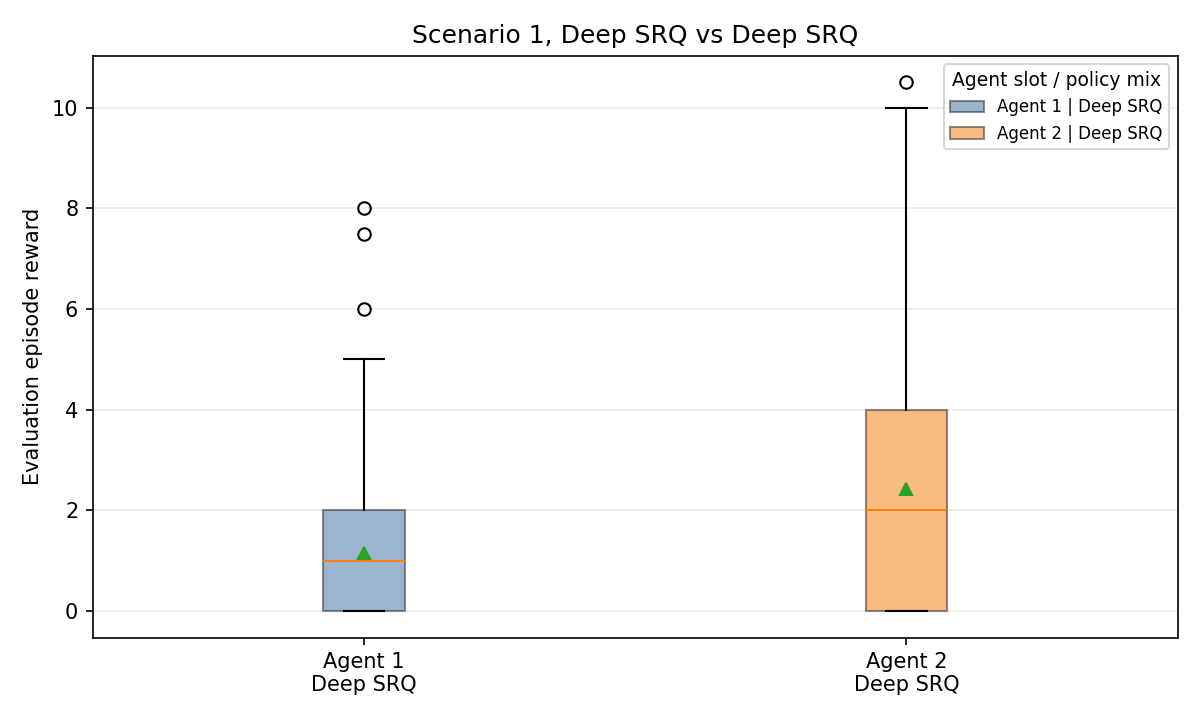

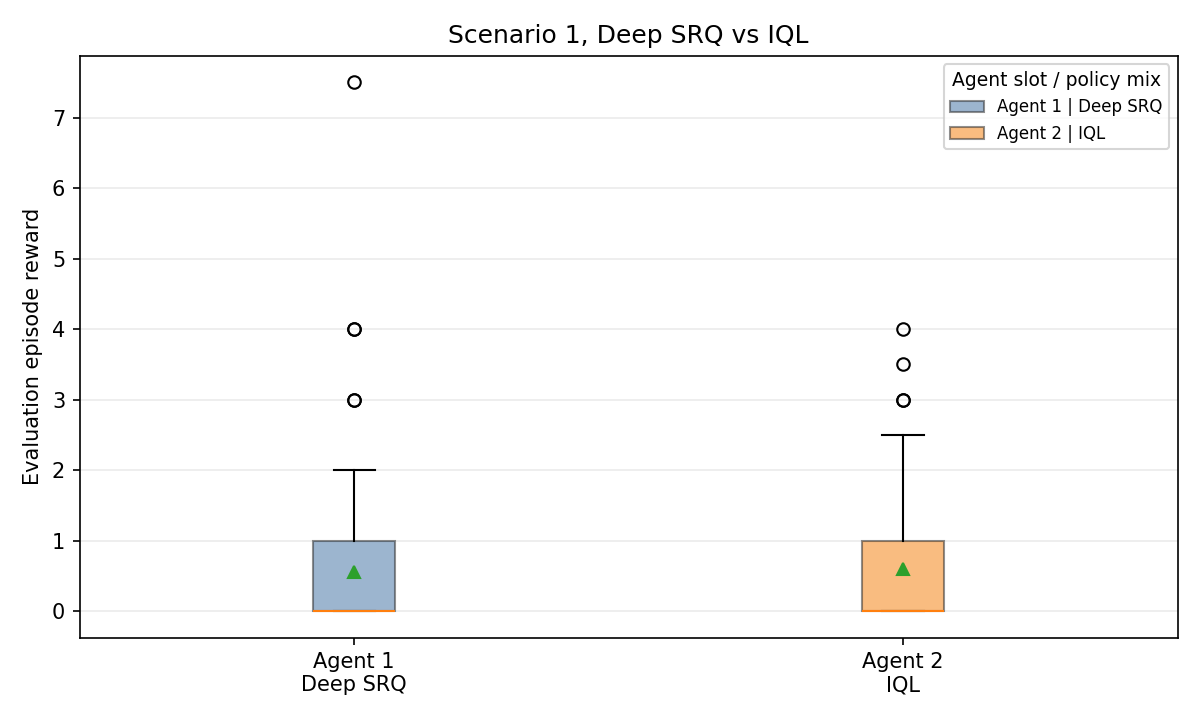

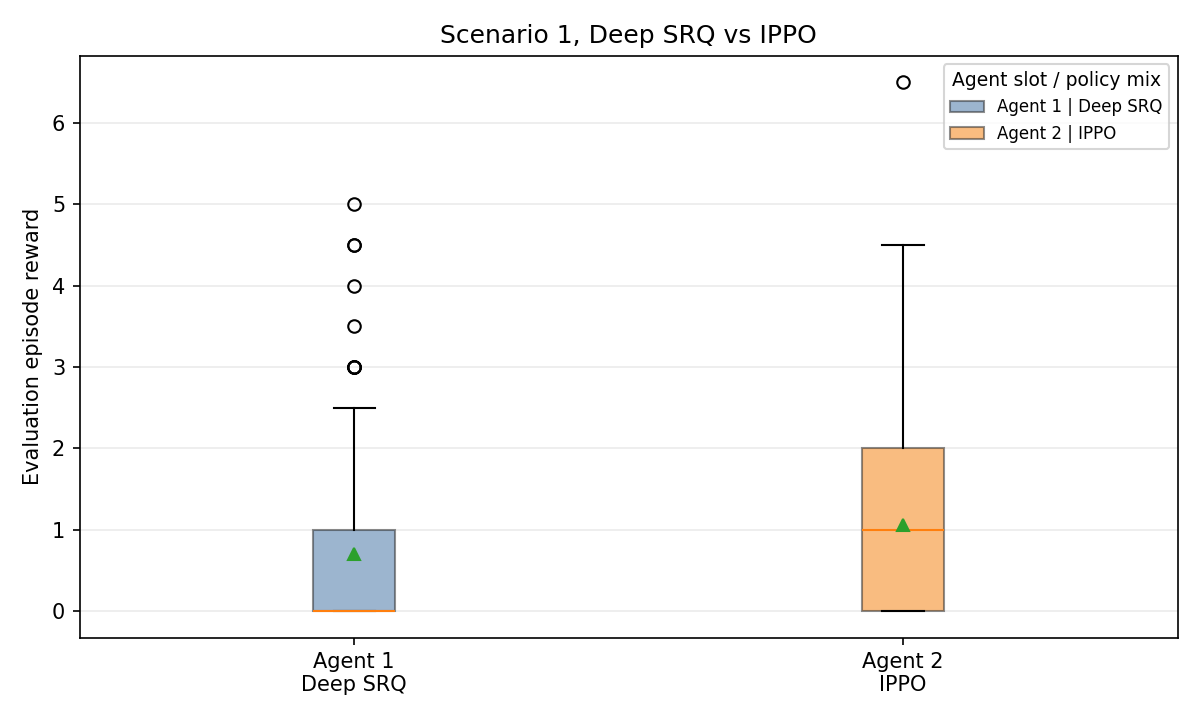

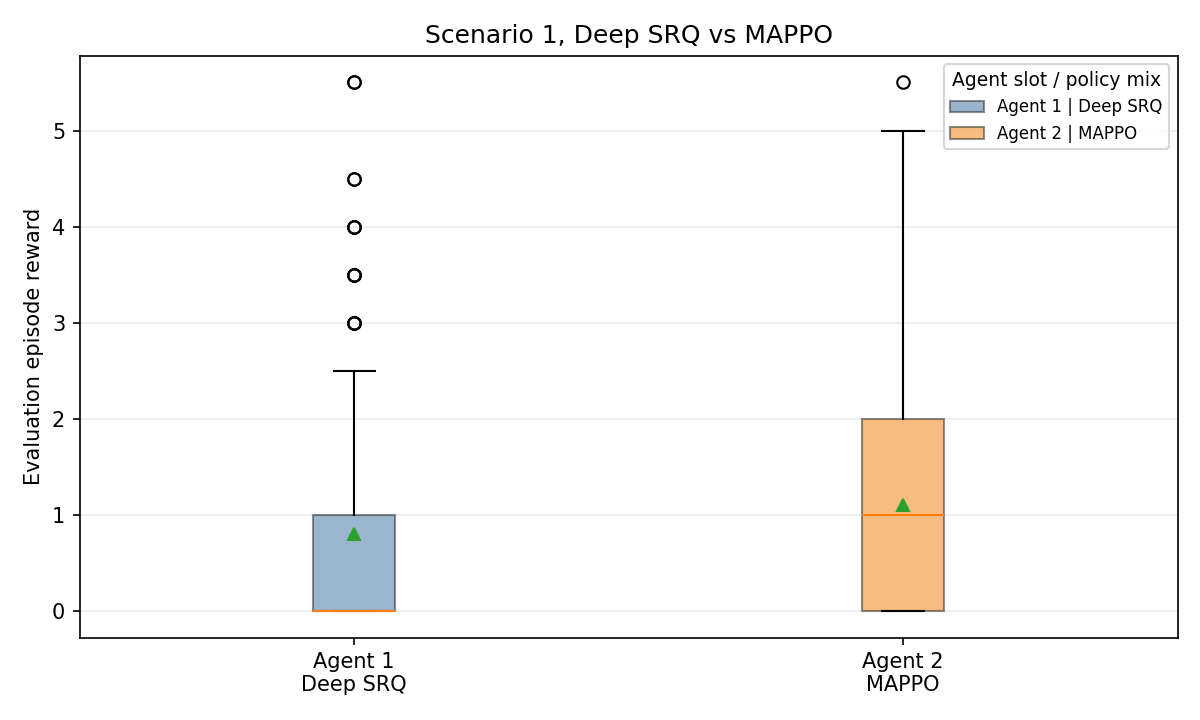

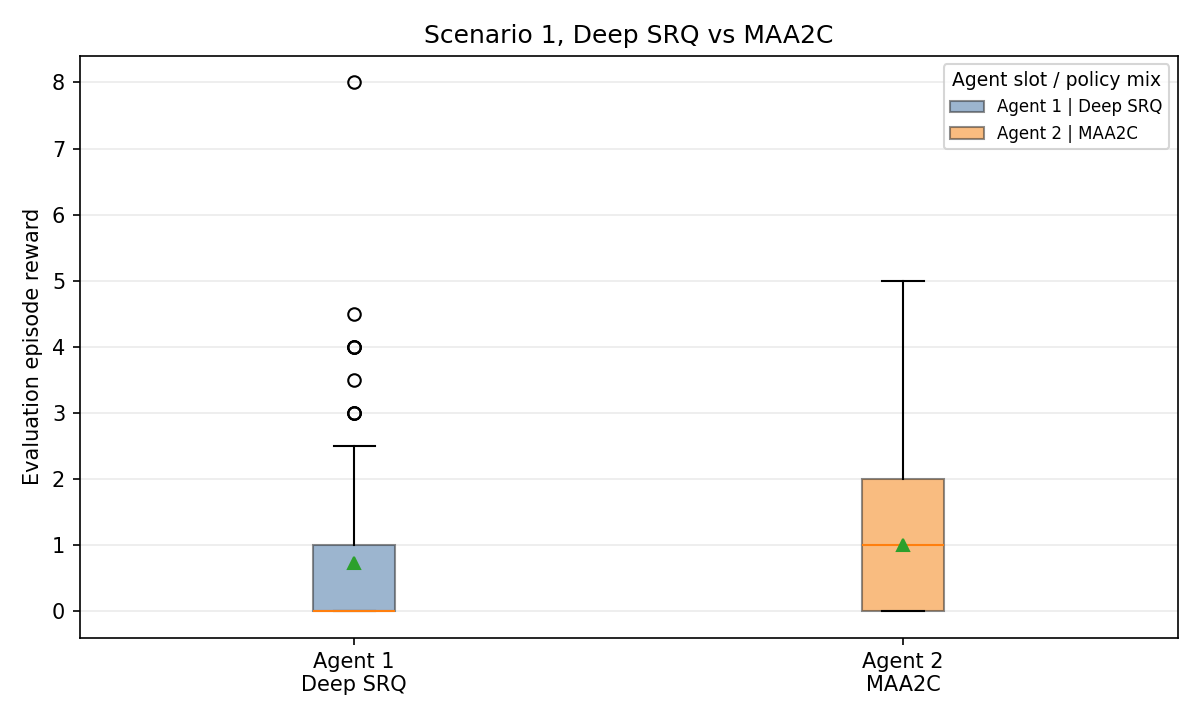

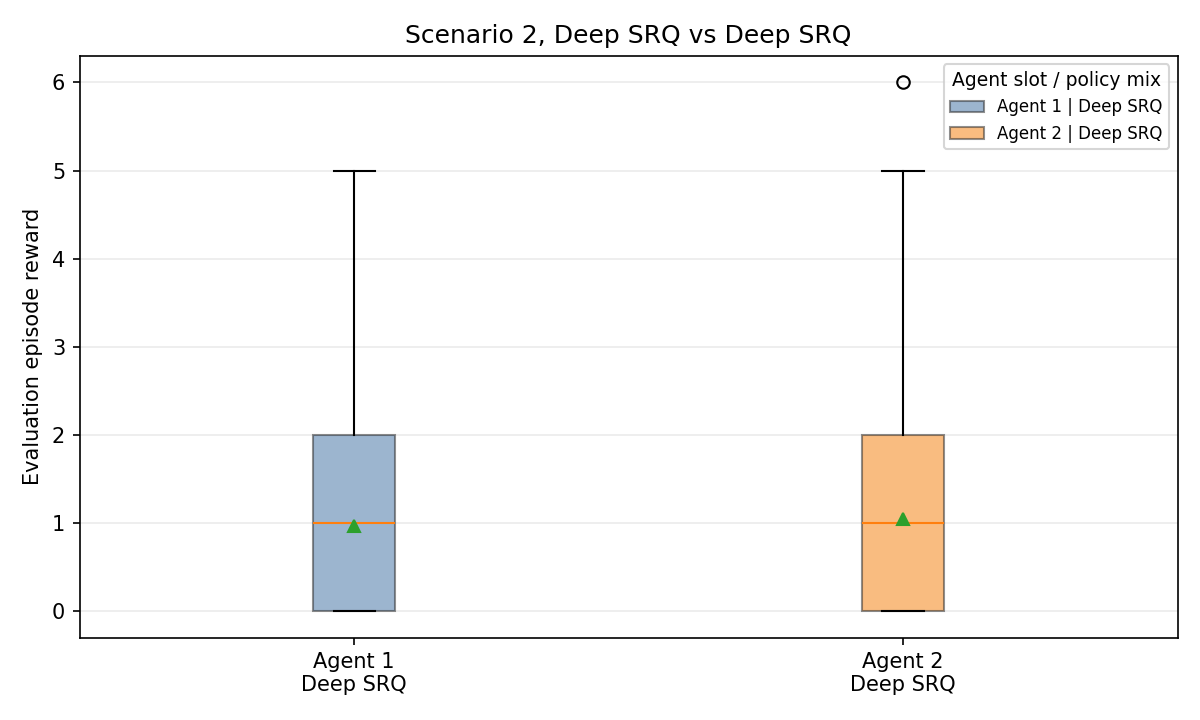

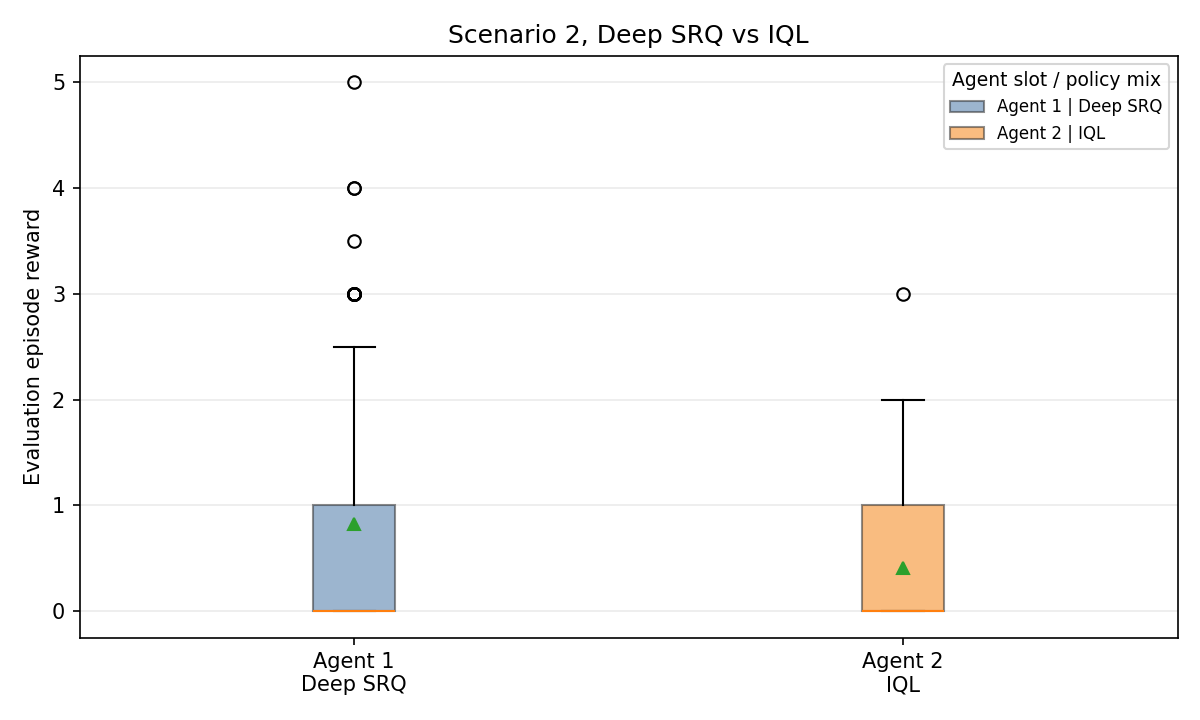

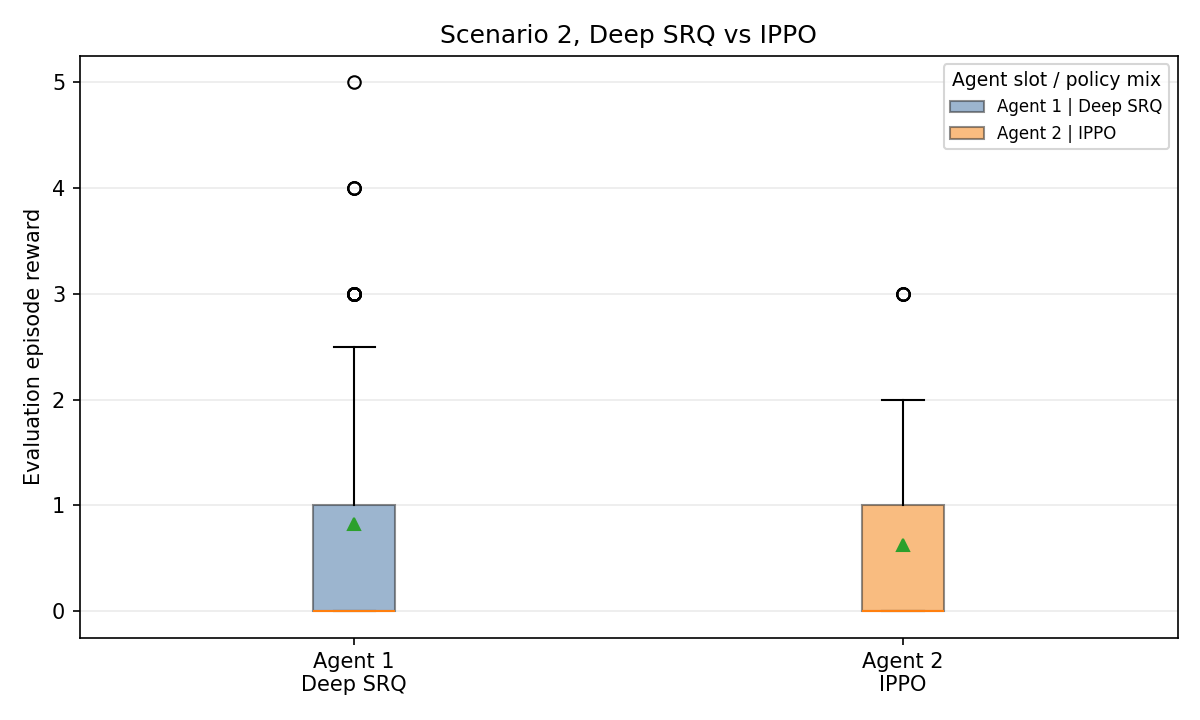

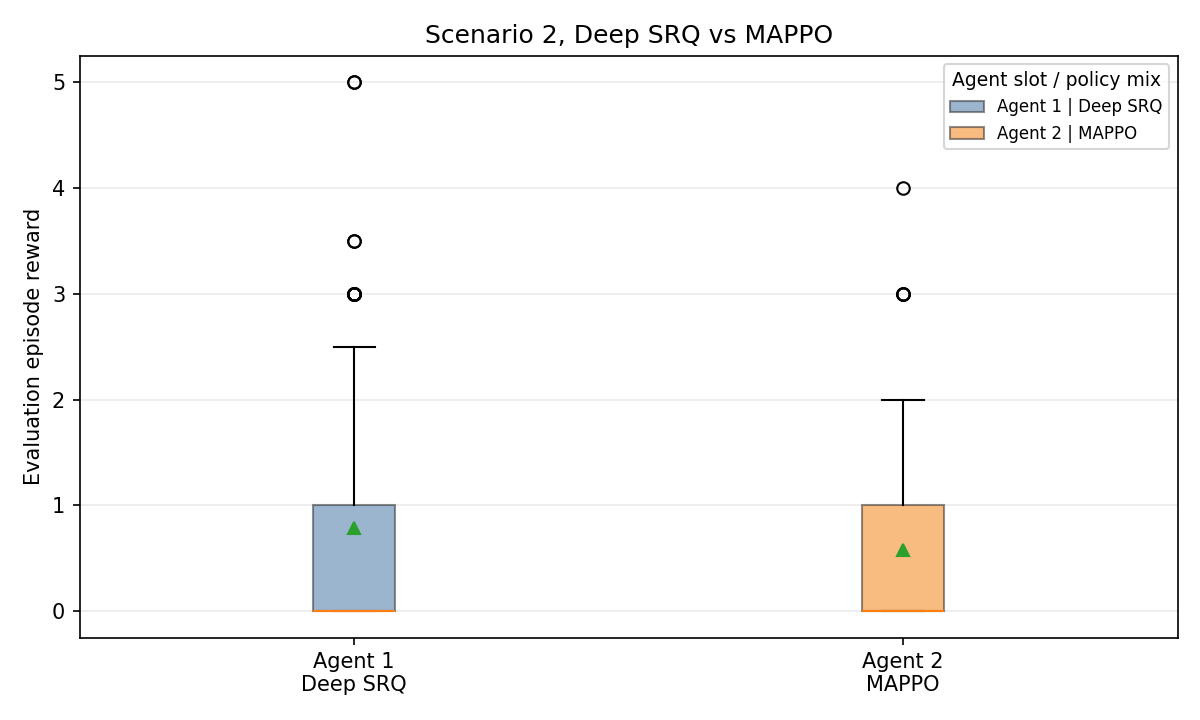

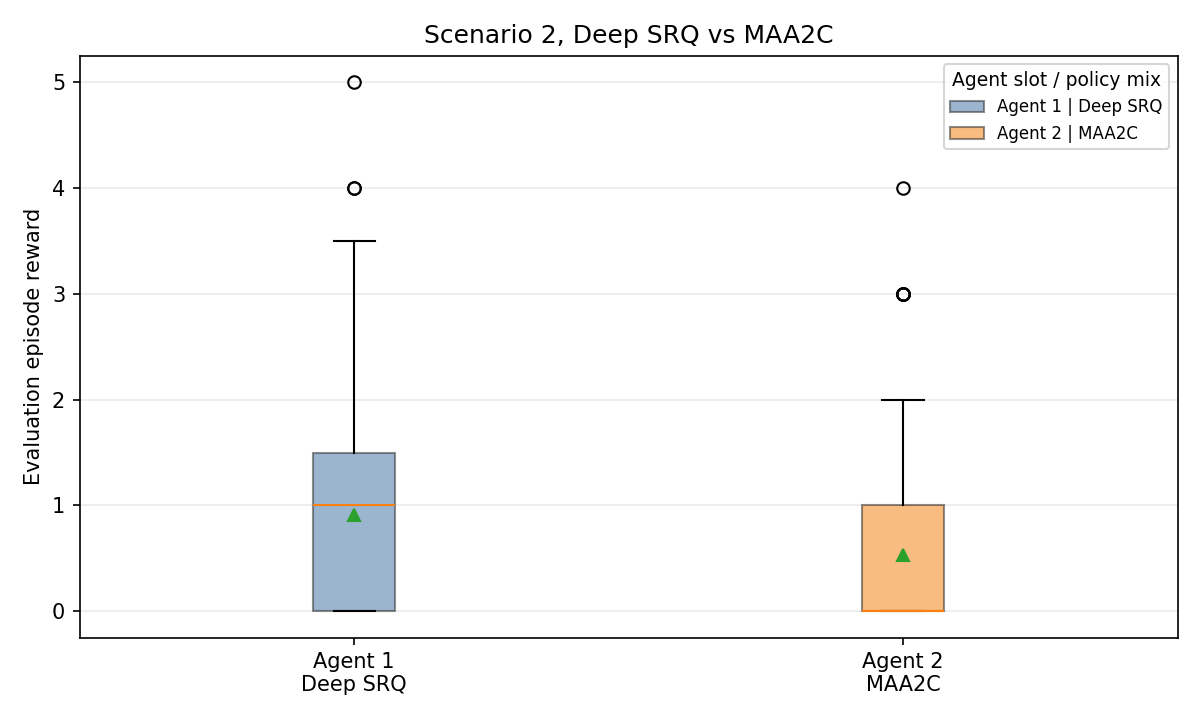

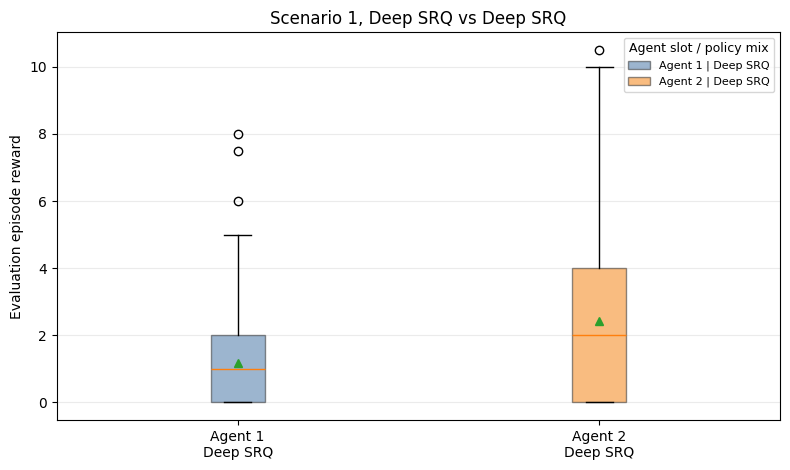

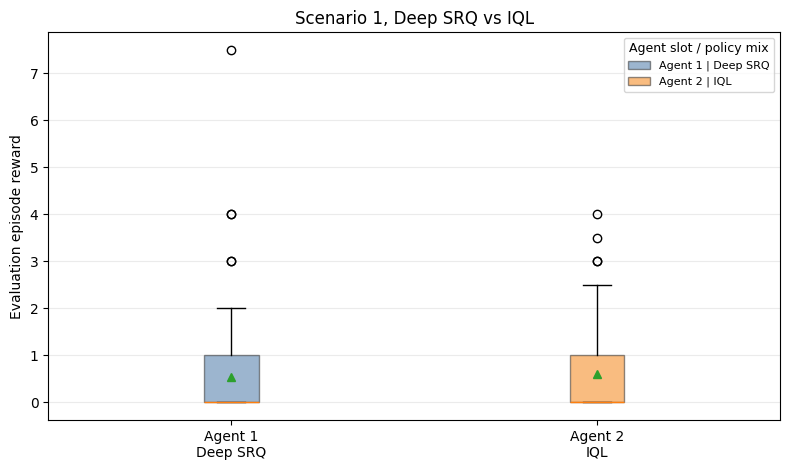

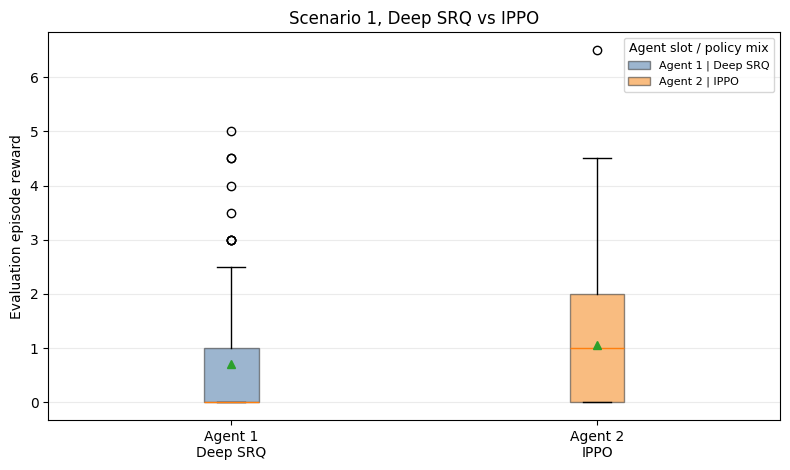

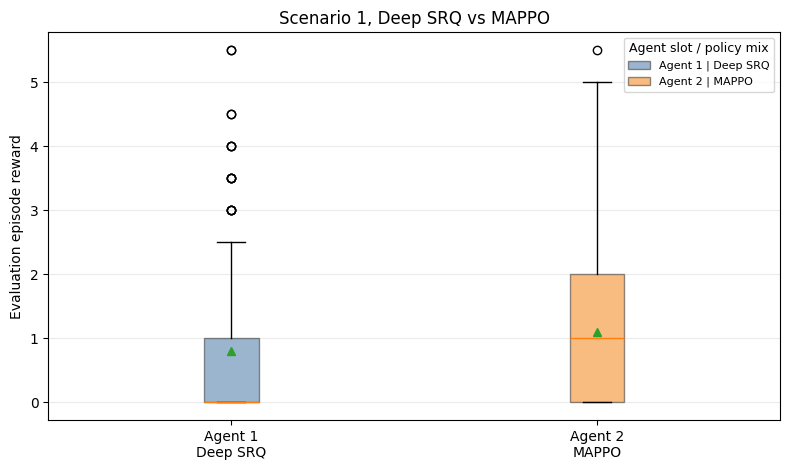

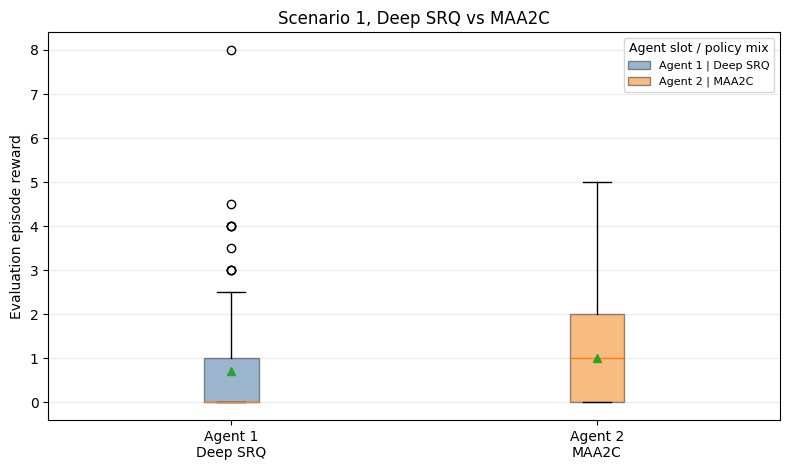

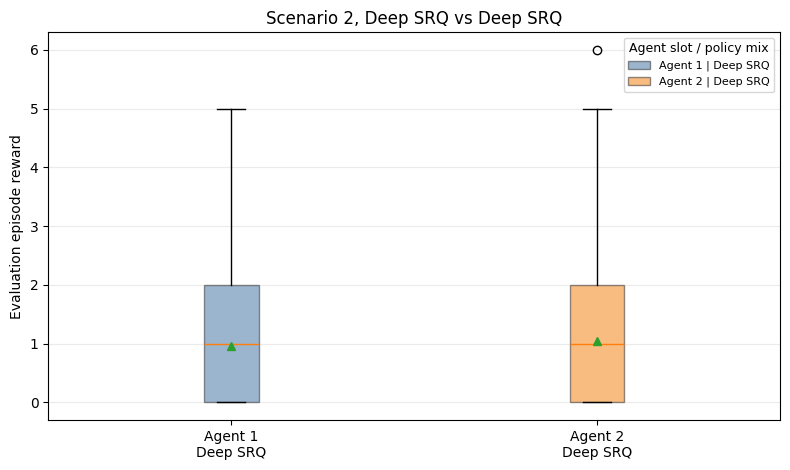

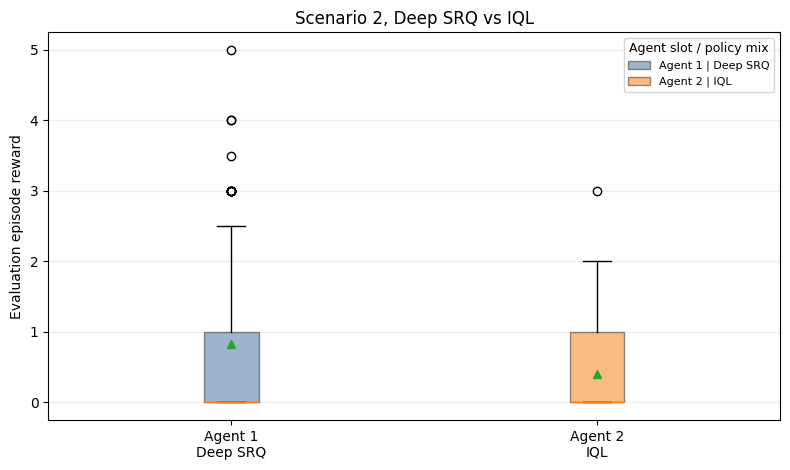

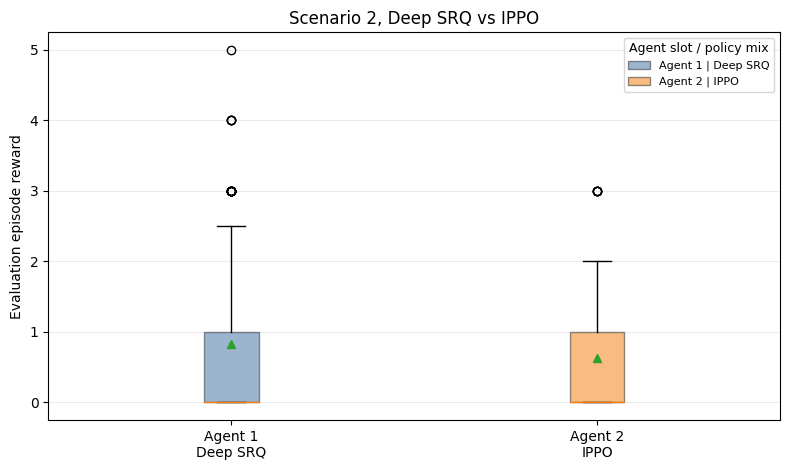

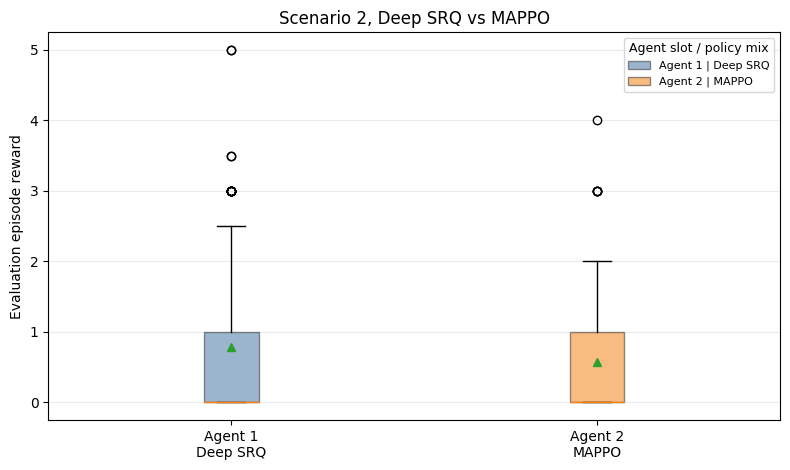

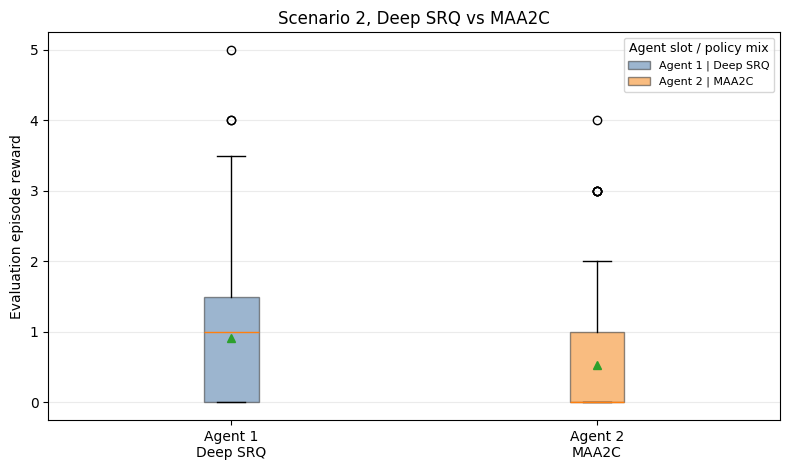

In [4]:
deep_srq_path_pool_eval_eps_0_01 = evaluate_deepsrq_path_mcp_pool_suite_for_epsilon(
    0.01,
    scenarios=SCENARIOS,
    n_episodes=EVAL_EPISODES,
    repo_root=REPO_ROOT,
    use_gpu=USE_GPU,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=EVAL_NUM_ENVS,
    hyperparameter_overrides=PATH_MCP_HYPERPARAMETER_OVERRIDES,
    nplayer_solver_name=PATH_POOL_NPLAYER_SOLVER,
)
display_evaluation_boxplots(deep_srq_path_pool_eval_eps_0_01)


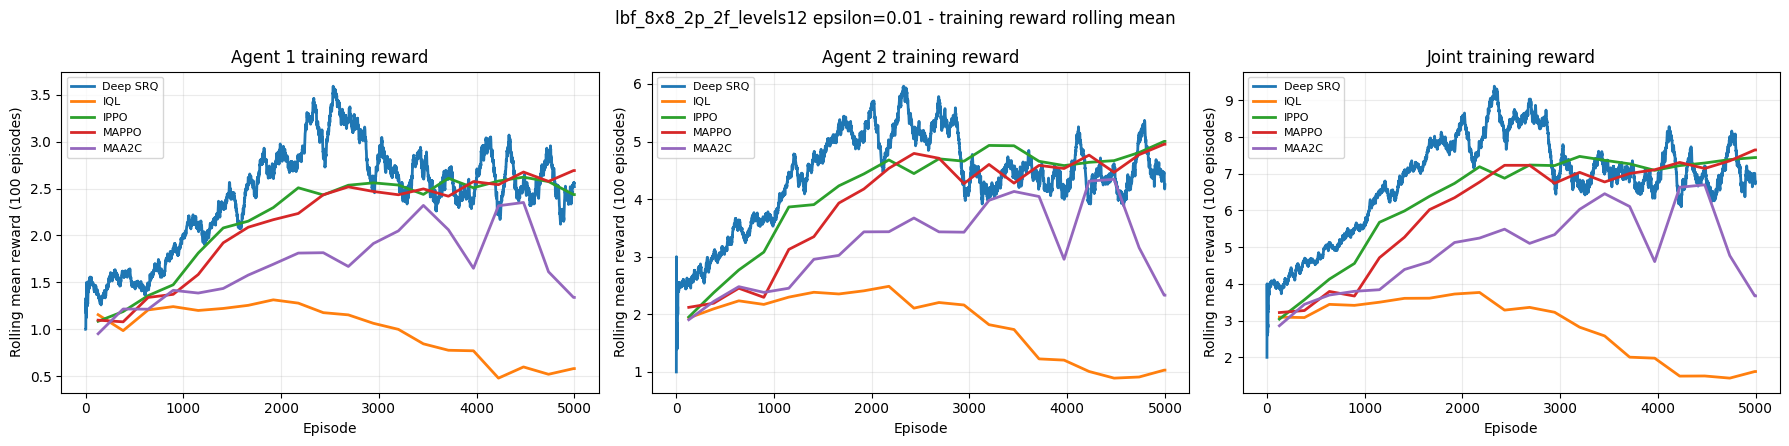

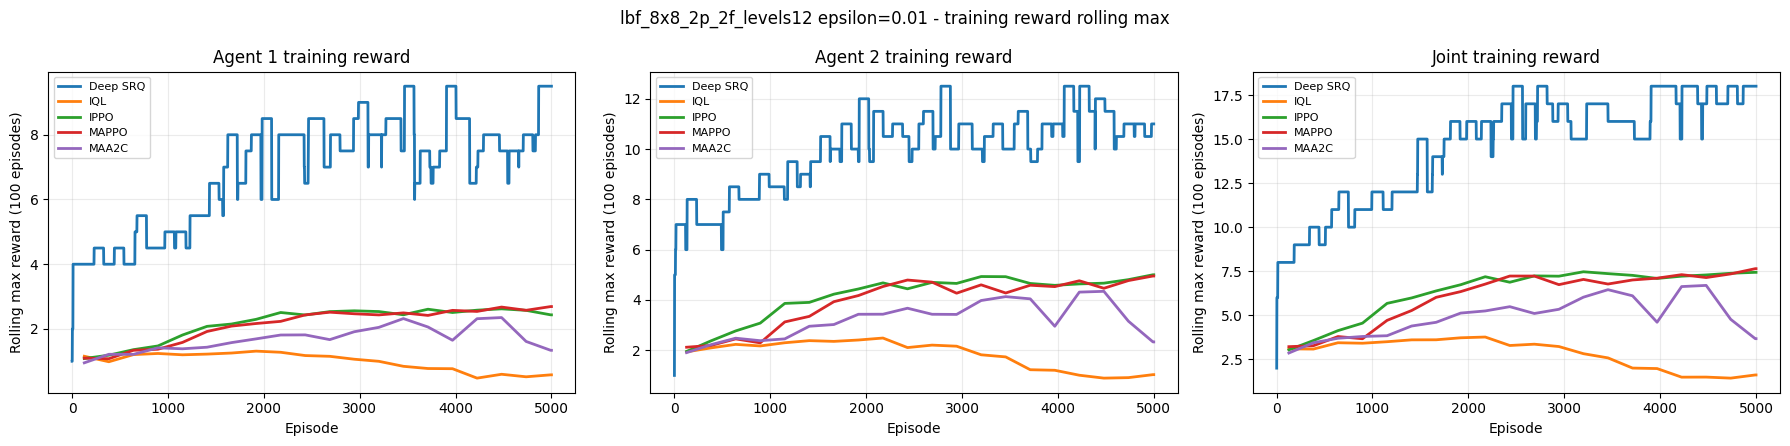

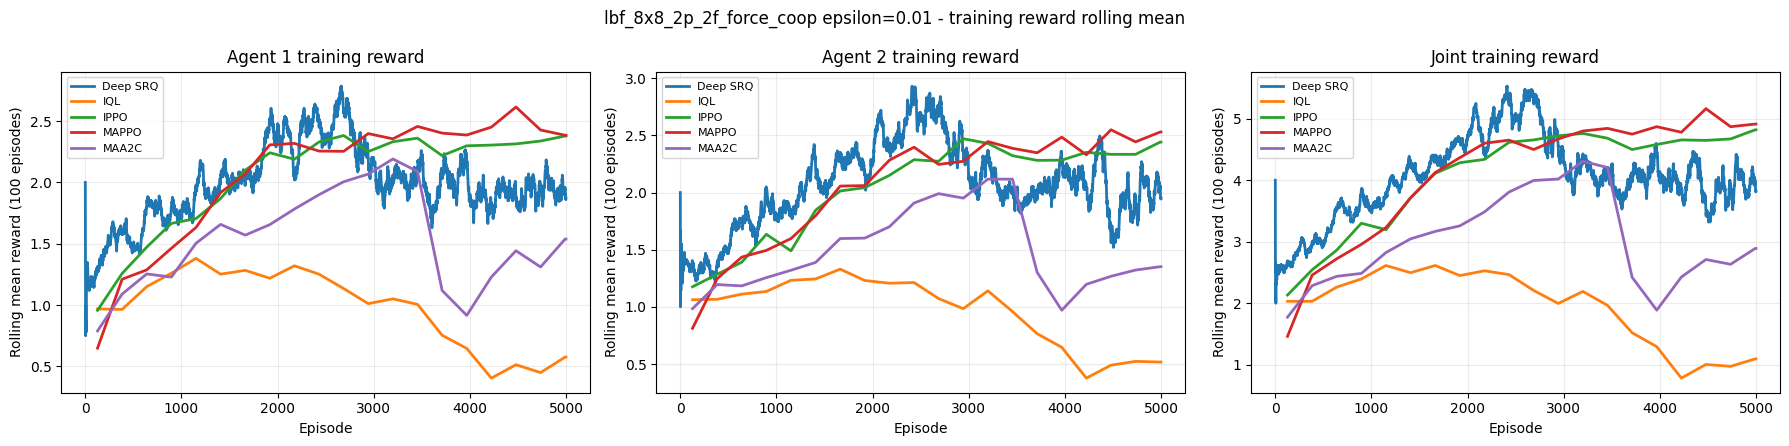

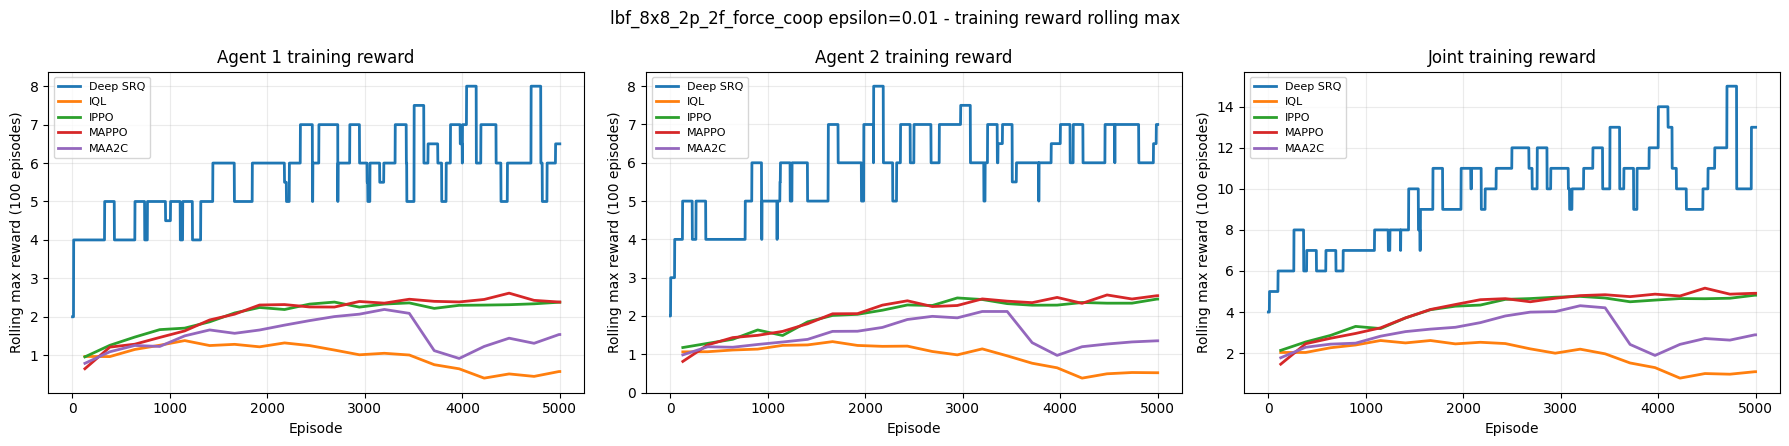

In [5]:
# PATH_POOL_TRAINING_REWARD_COMPARISON_CALL
plot_path_pool_training_reward_comparisons(0.01, scenarios=SCENARIOS)


## Robust epsilon 0.1

lbf_8x8_2p_2f_levels12 | Deep SRQ:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs IQL:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs IPPO:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs MAPPO:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs MAA2C:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ vs IQL:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ vs IPPO:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ vs MAPPO:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ vs MAA2C:   0%|          | 0/200 [00:00<?, ?episode/s]

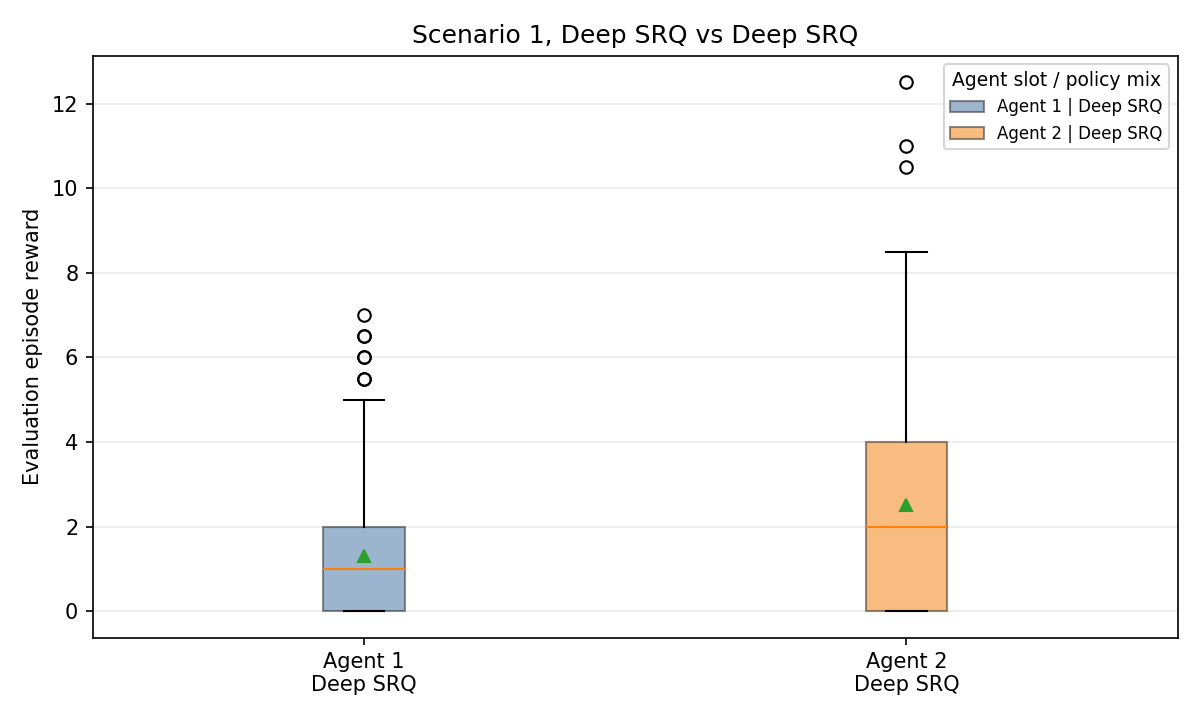

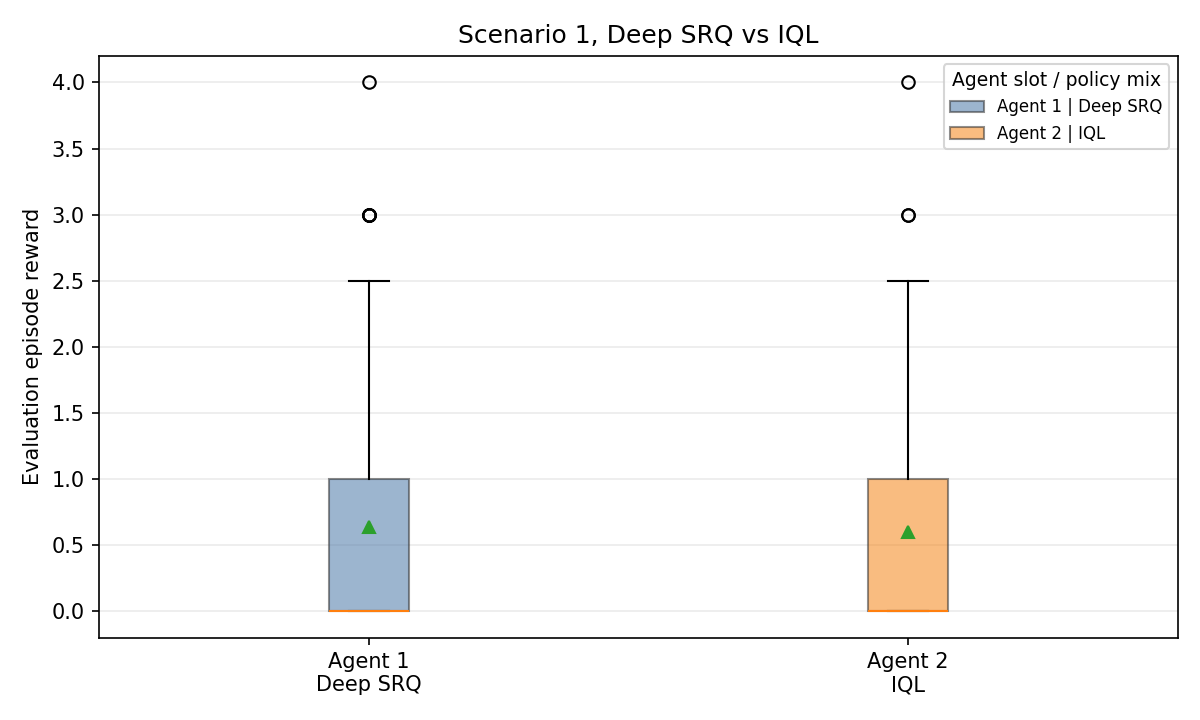

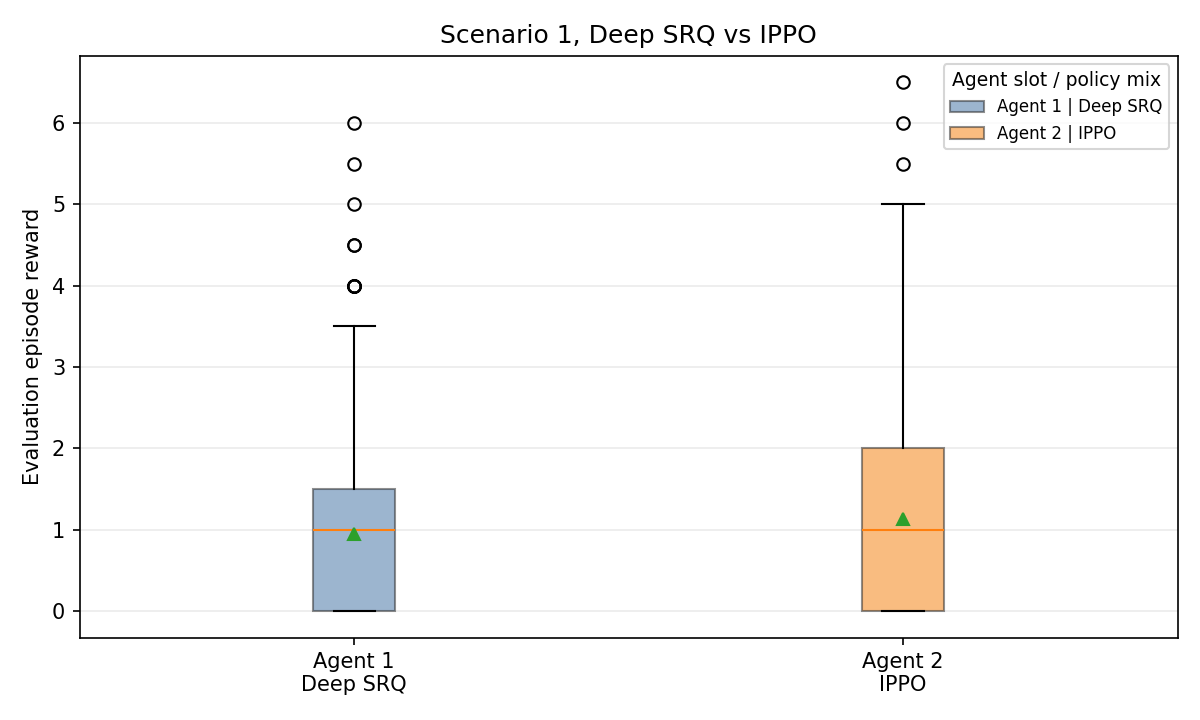

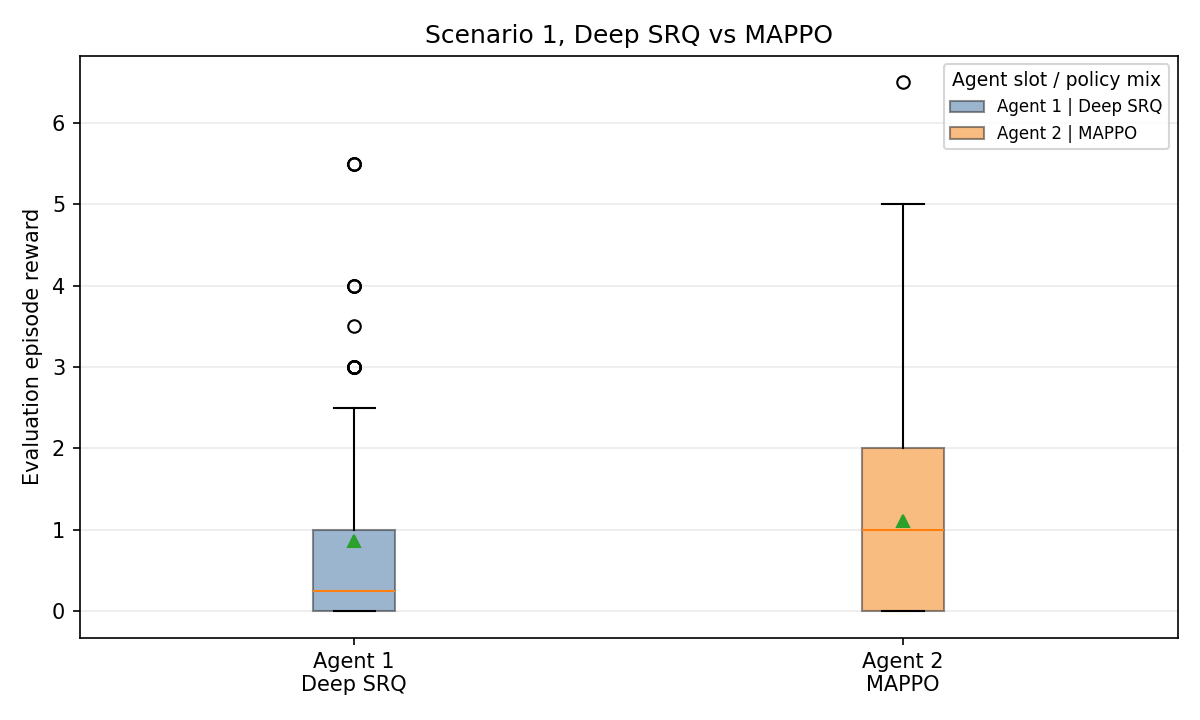

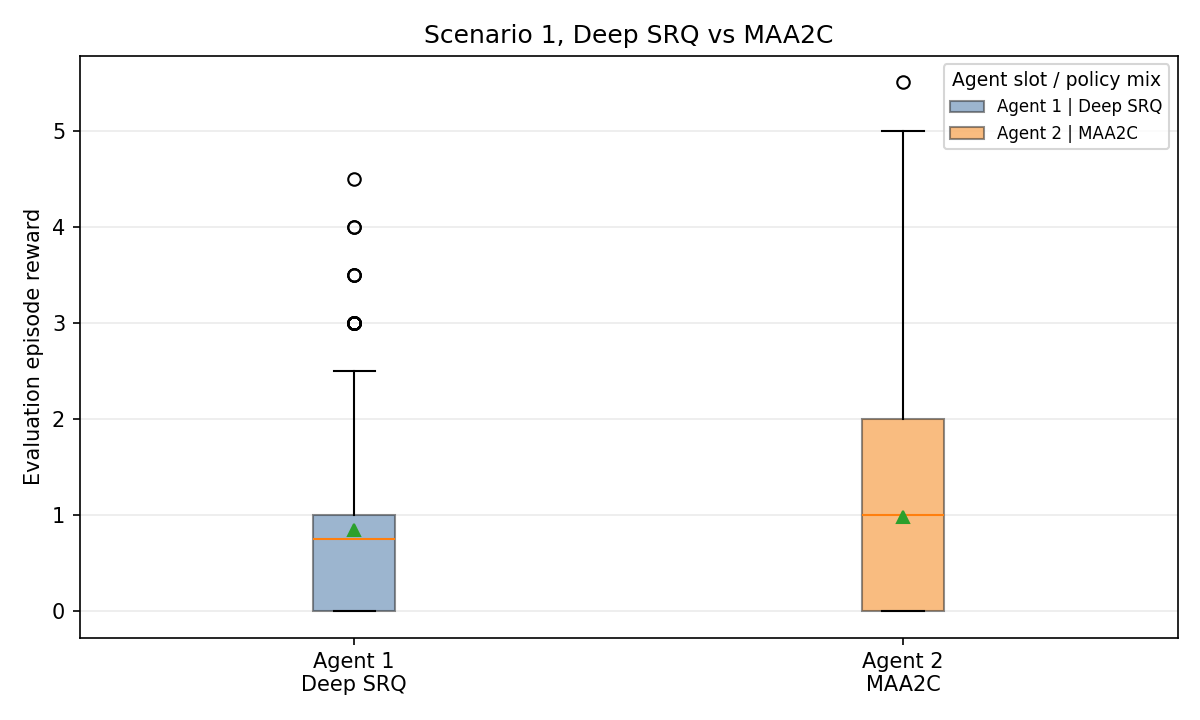

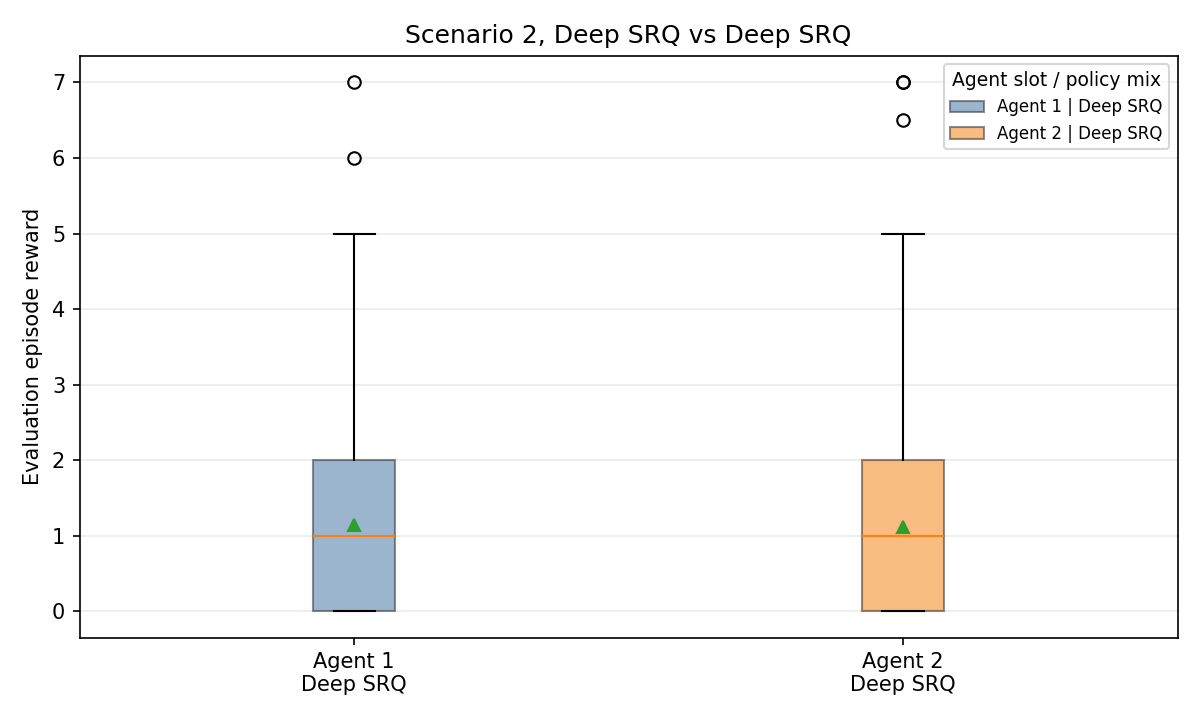

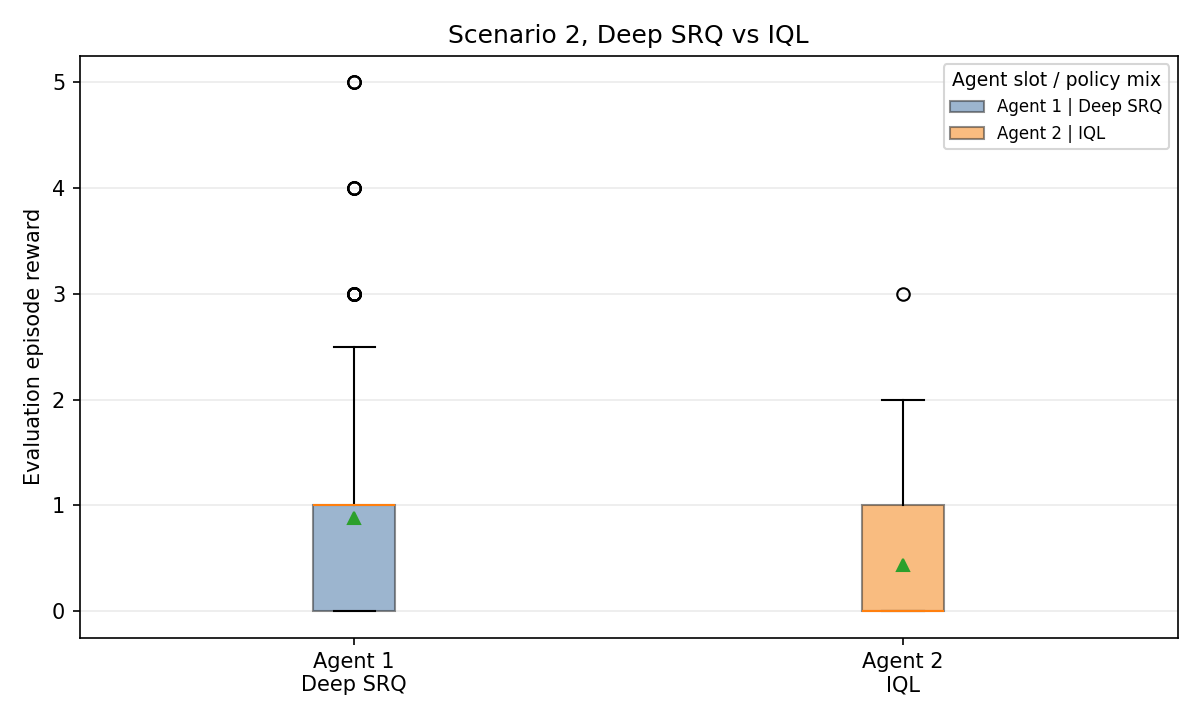

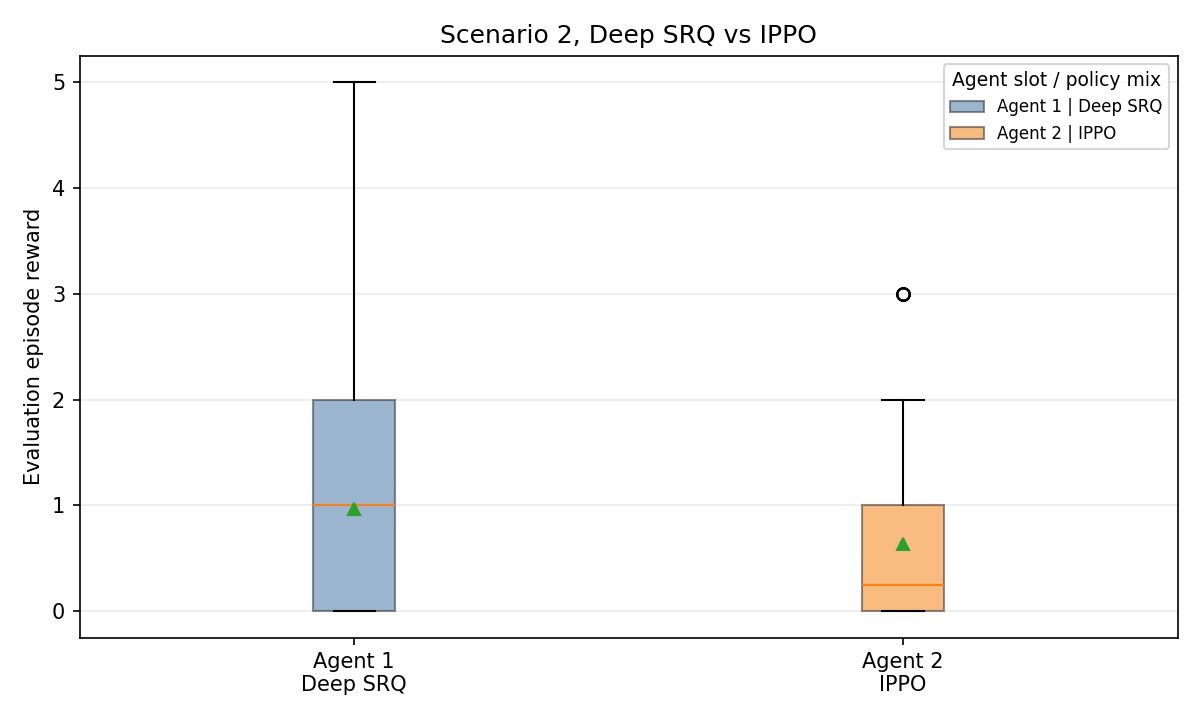

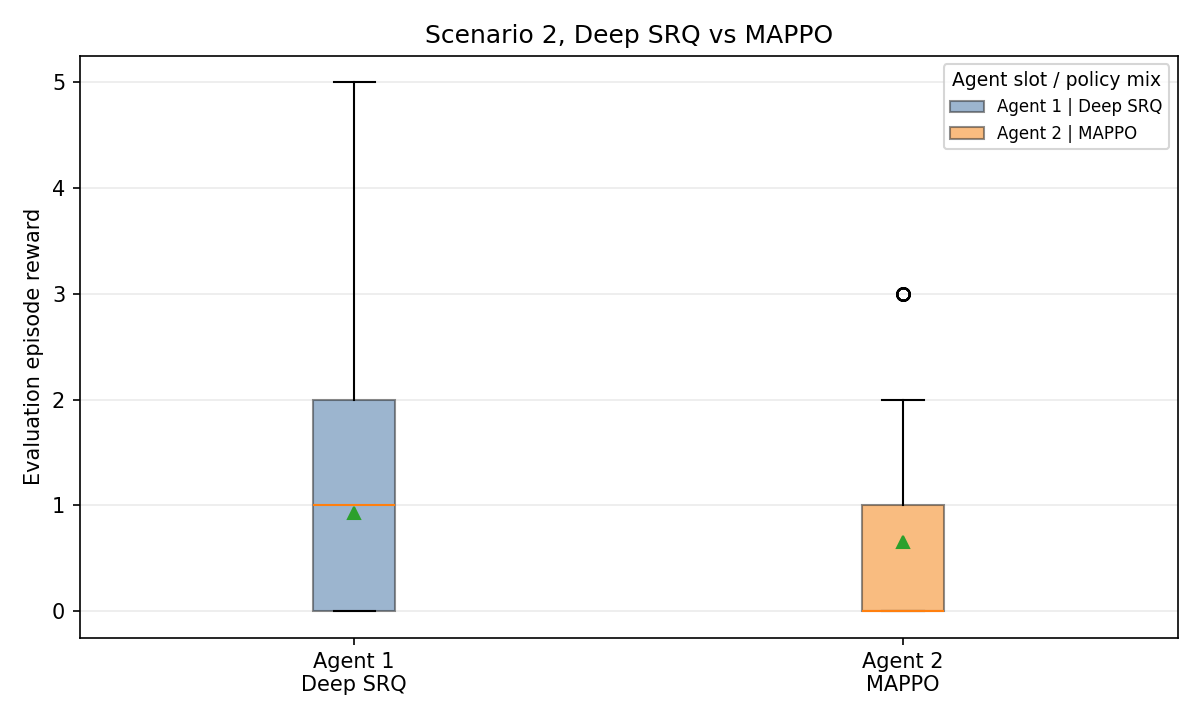

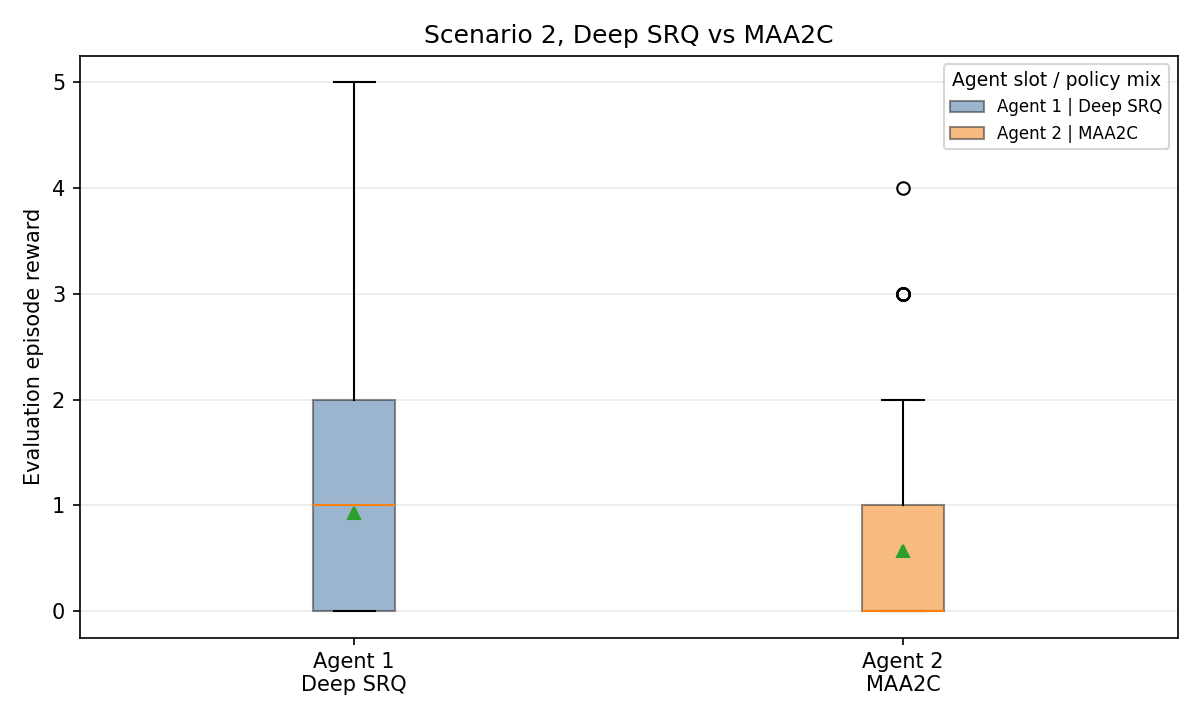

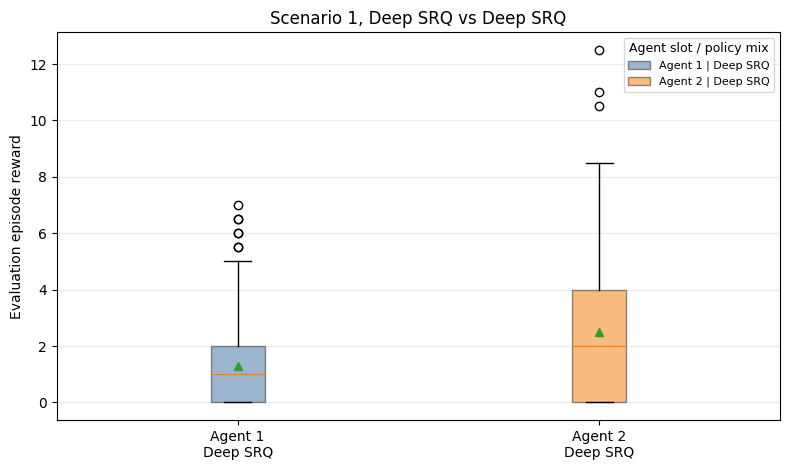

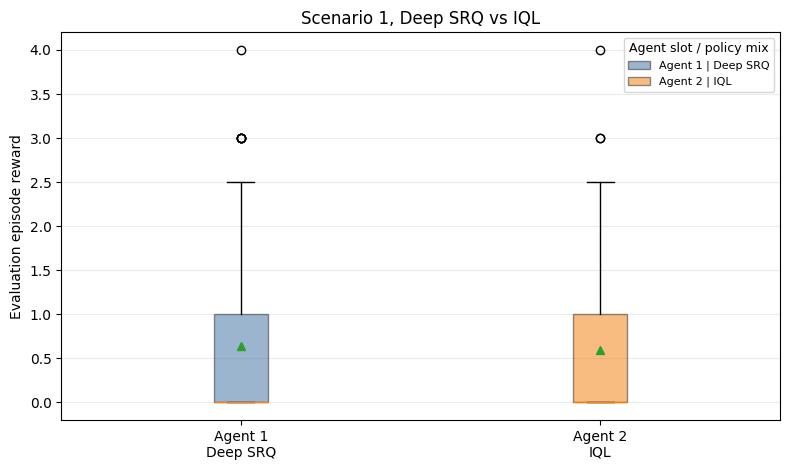

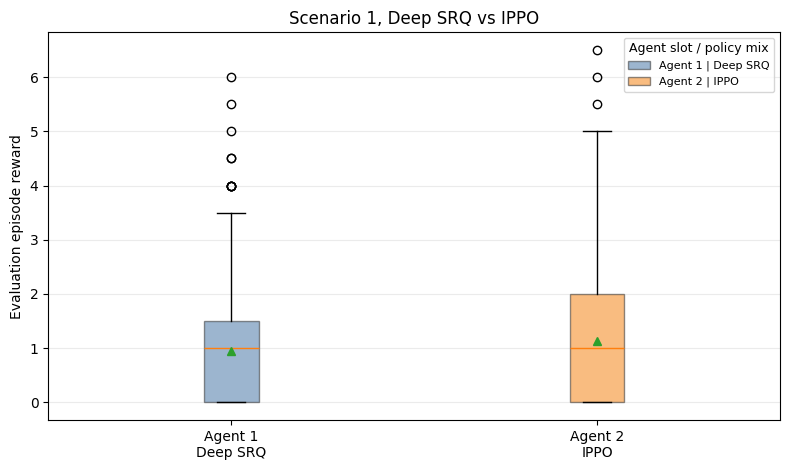

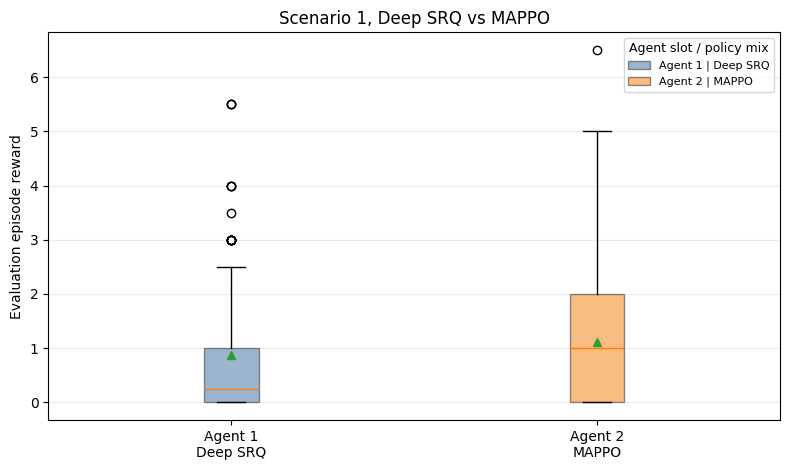

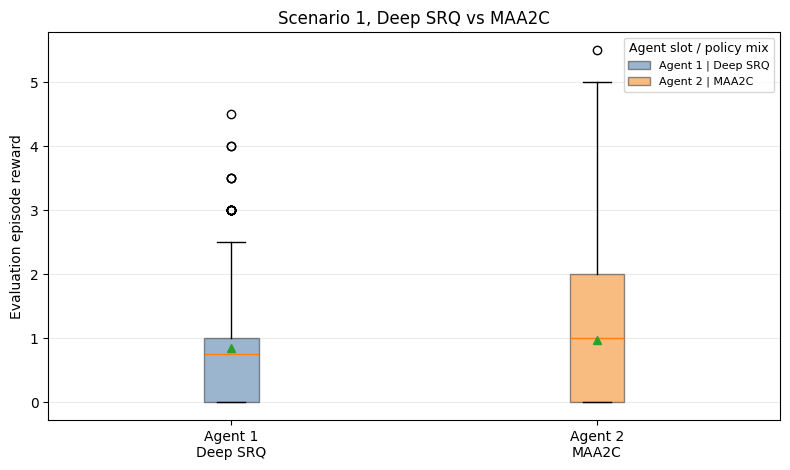

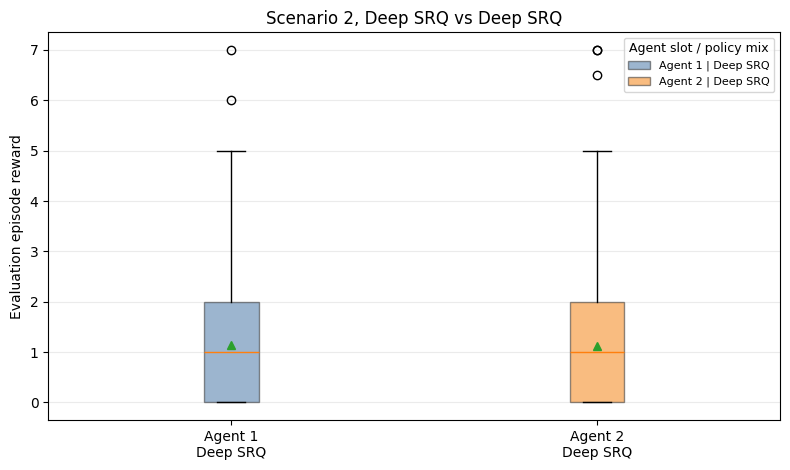

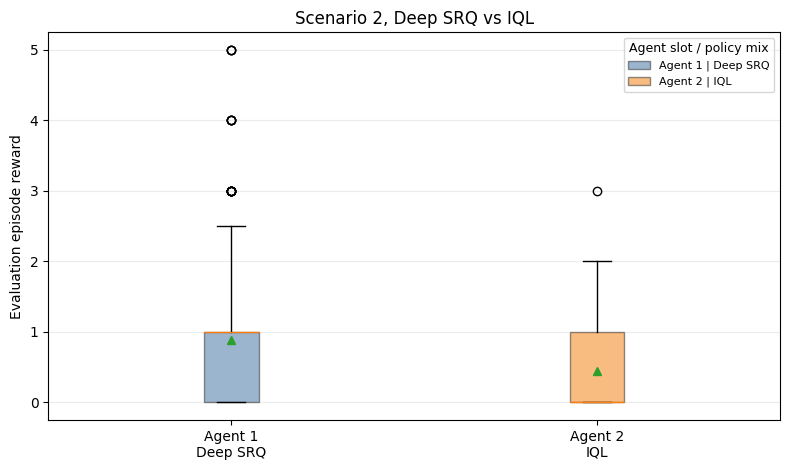

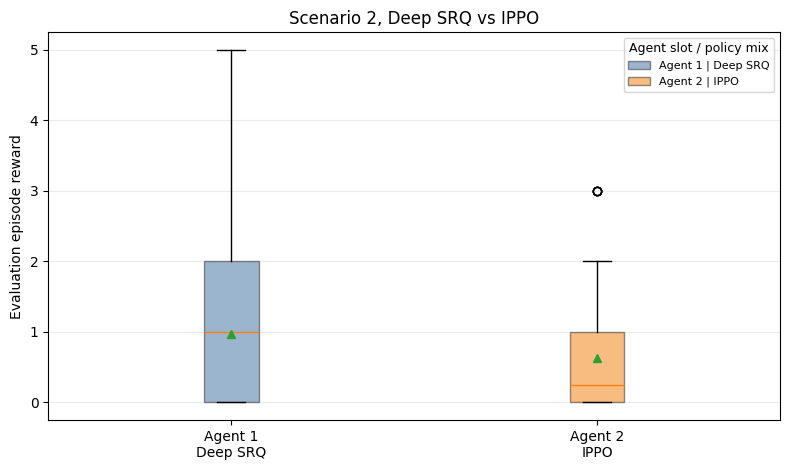

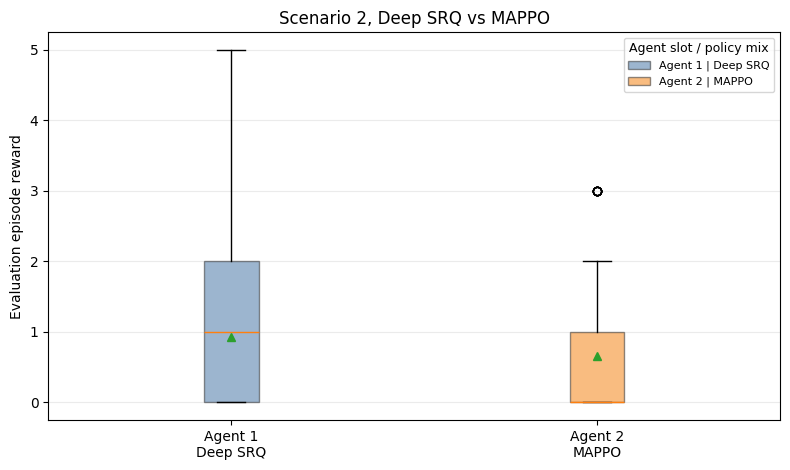

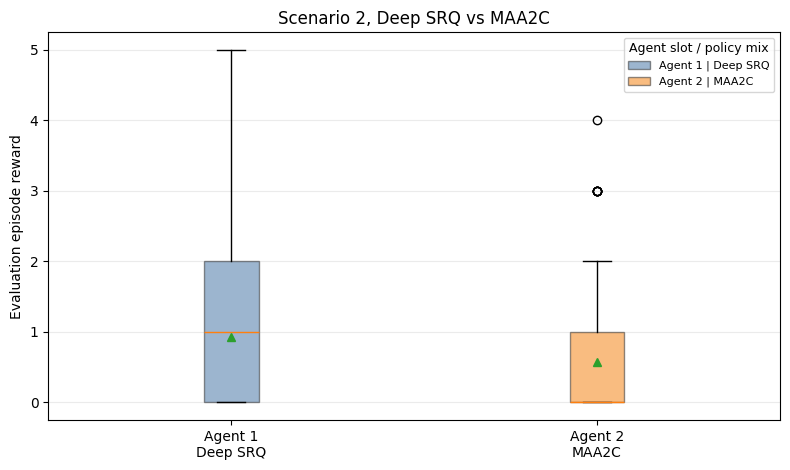

In [6]:
deep_srq_path_pool_eval_eps_0_1 = evaluate_deepsrq_path_mcp_pool_suite_for_epsilon(
    0.1,
    scenarios=SCENARIOS,
    n_episodes=EVAL_EPISODES,
    repo_root=REPO_ROOT,
    use_gpu=USE_GPU,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=EVAL_NUM_ENVS,
    hyperparameter_overrides=PATH_MCP_HYPERPARAMETER_OVERRIDES,
    nplayer_solver_name=PATH_POOL_NPLAYER_SOLVER,
)
display_evaluation_boxplots(deep_srq_path_pool_eval_eps_0_1)


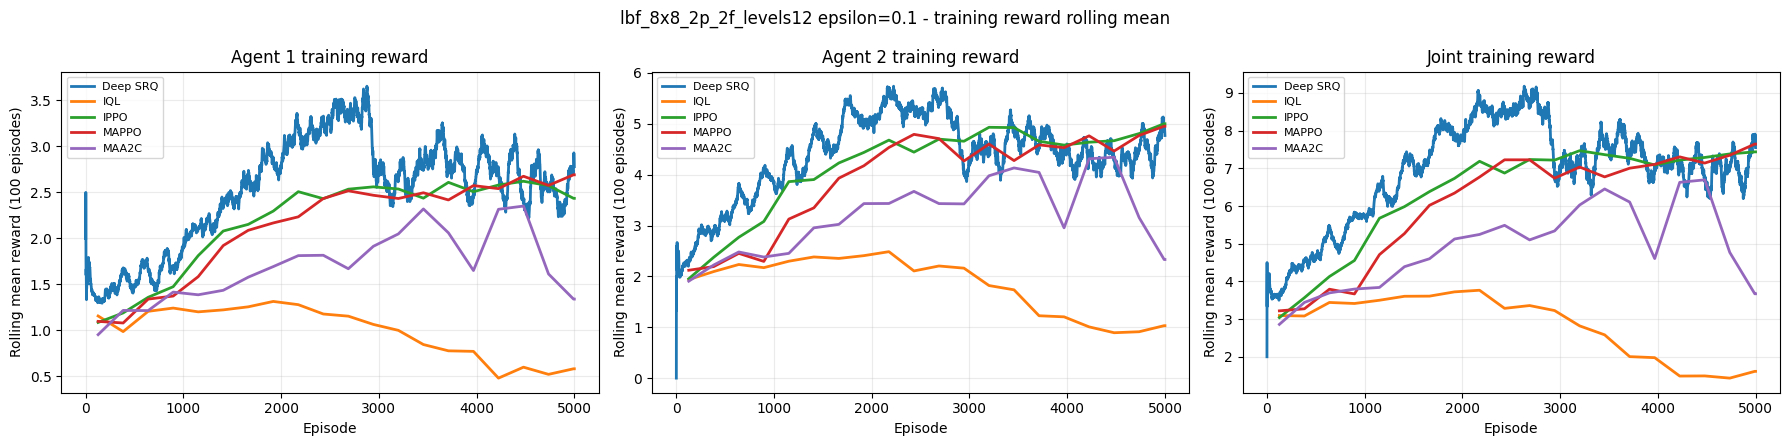

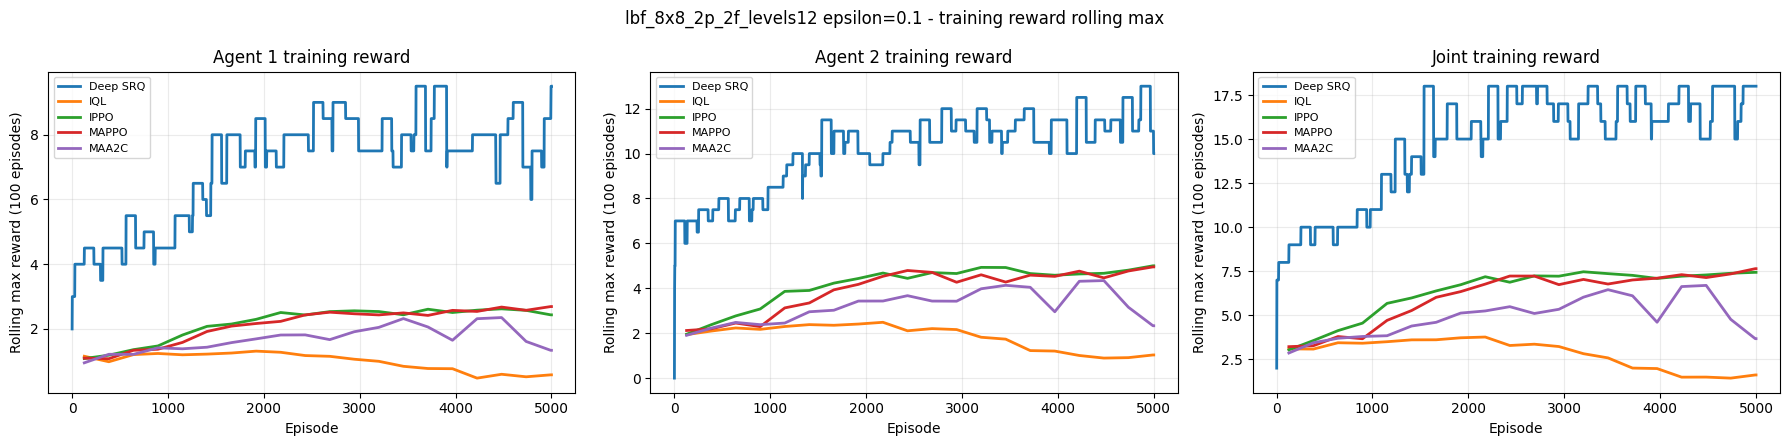

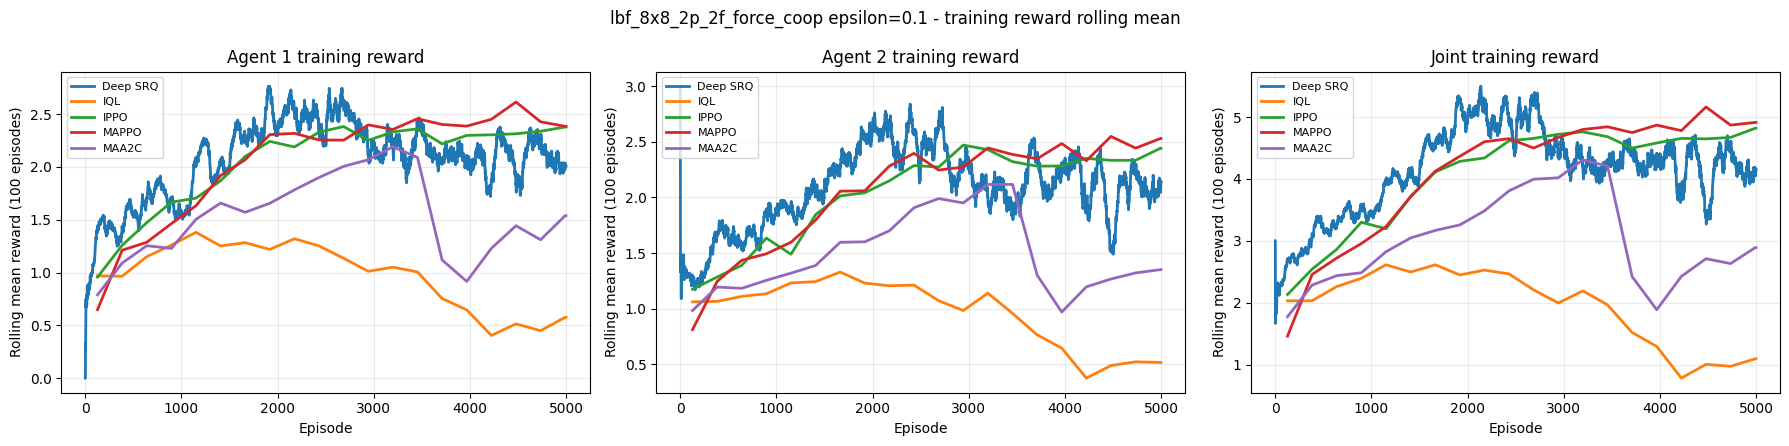

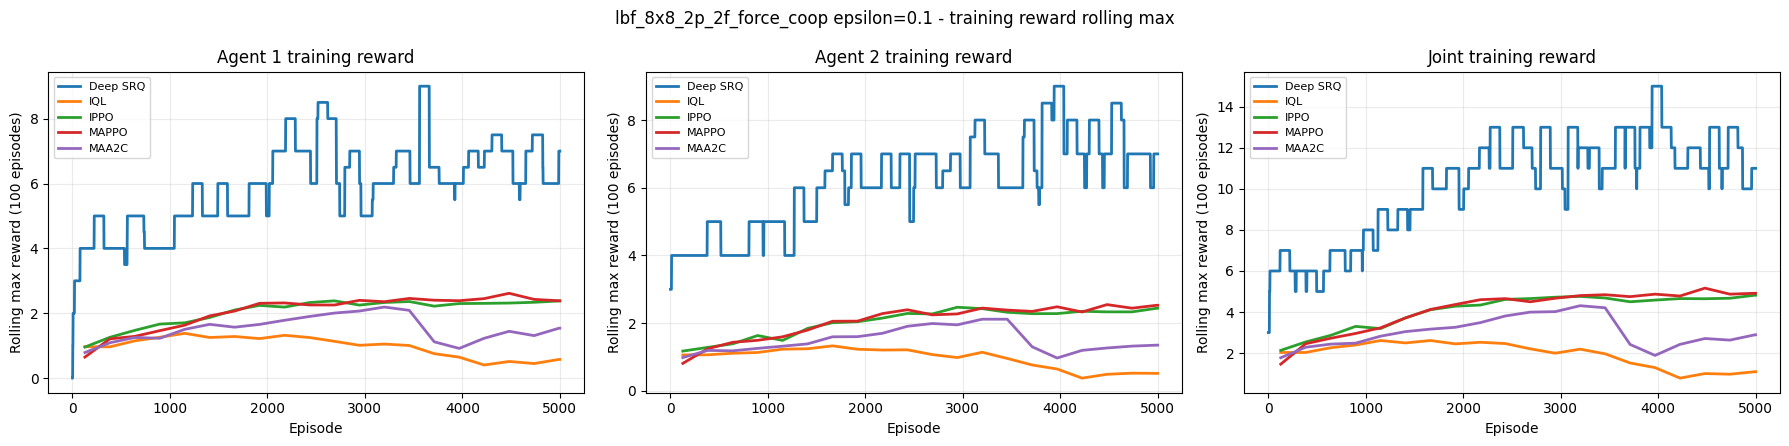

In [7]:
# PATH_POOL_TRAINING_REWARD_COMPARISON_CALL
plot_path_pool_training_reward_comparisons(0.1, scenarios=SCENARIOS)


## Robust epsilon 0.5

lbf_8x8_2p_2f_levels12 | Deep SRQ:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs IQL:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs IPPO:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs MAPPO:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs MAA2C:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ vs IQL:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ vs IPPO:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ vs MAPPO:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ vs MAA2C:   0%|          | 0/200 [00:00<?, ?episode/s]

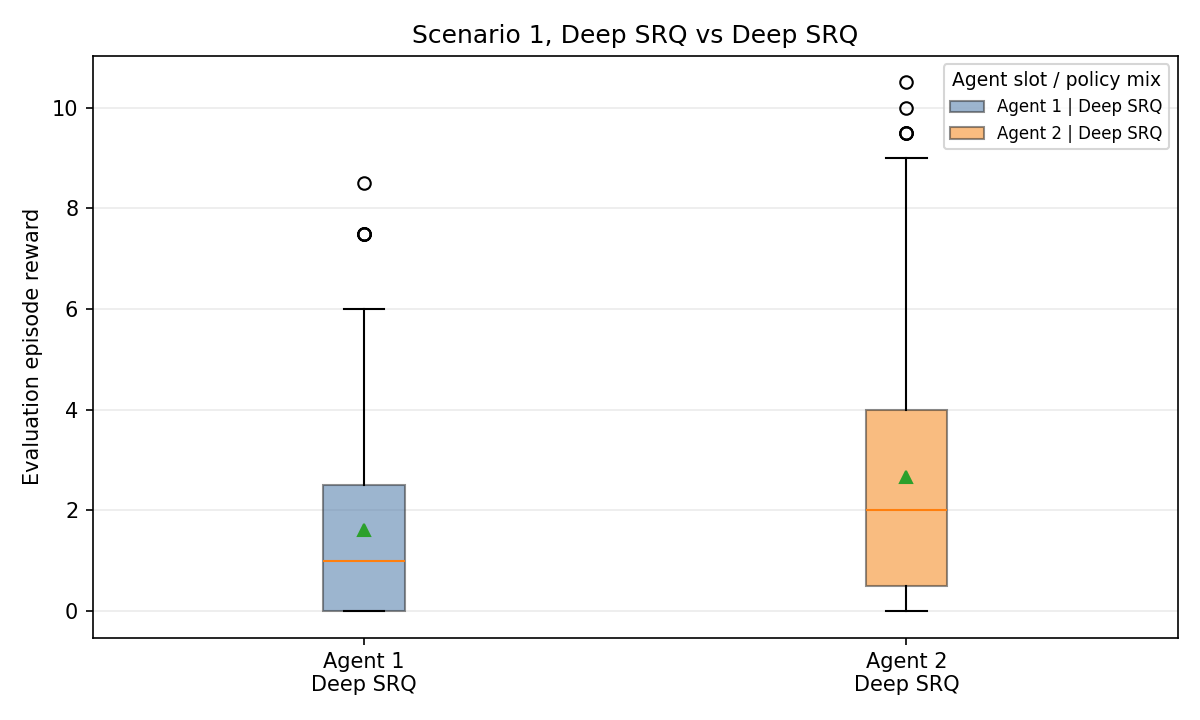

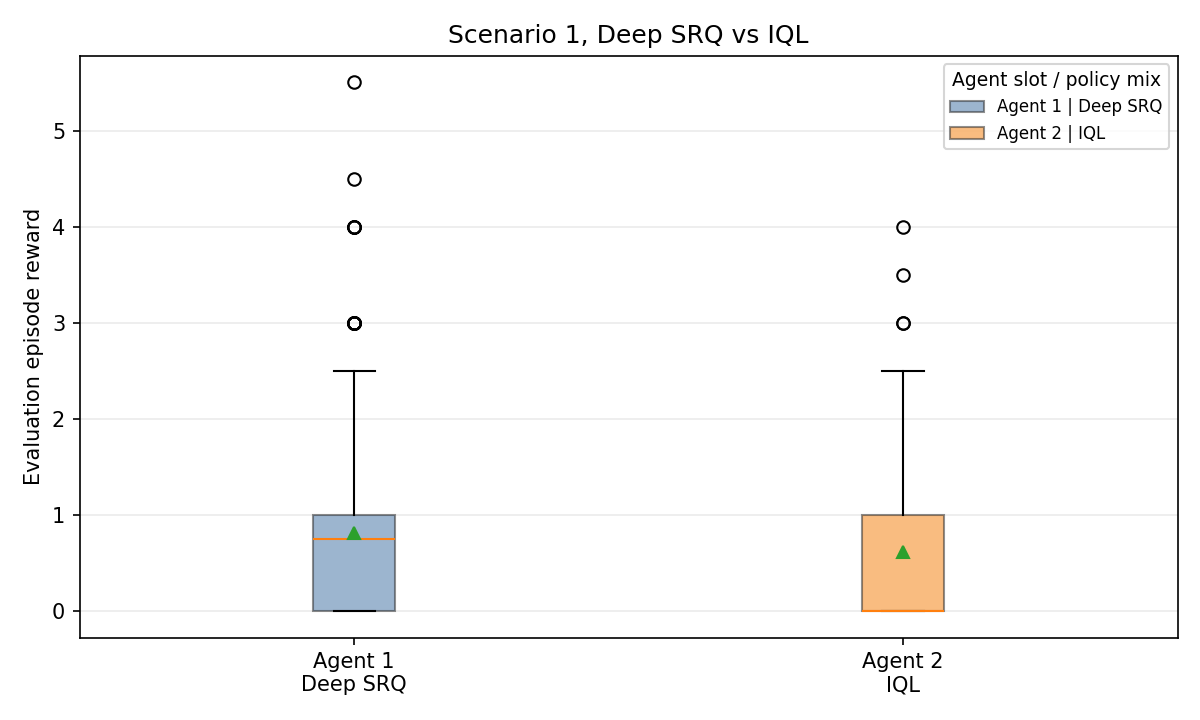

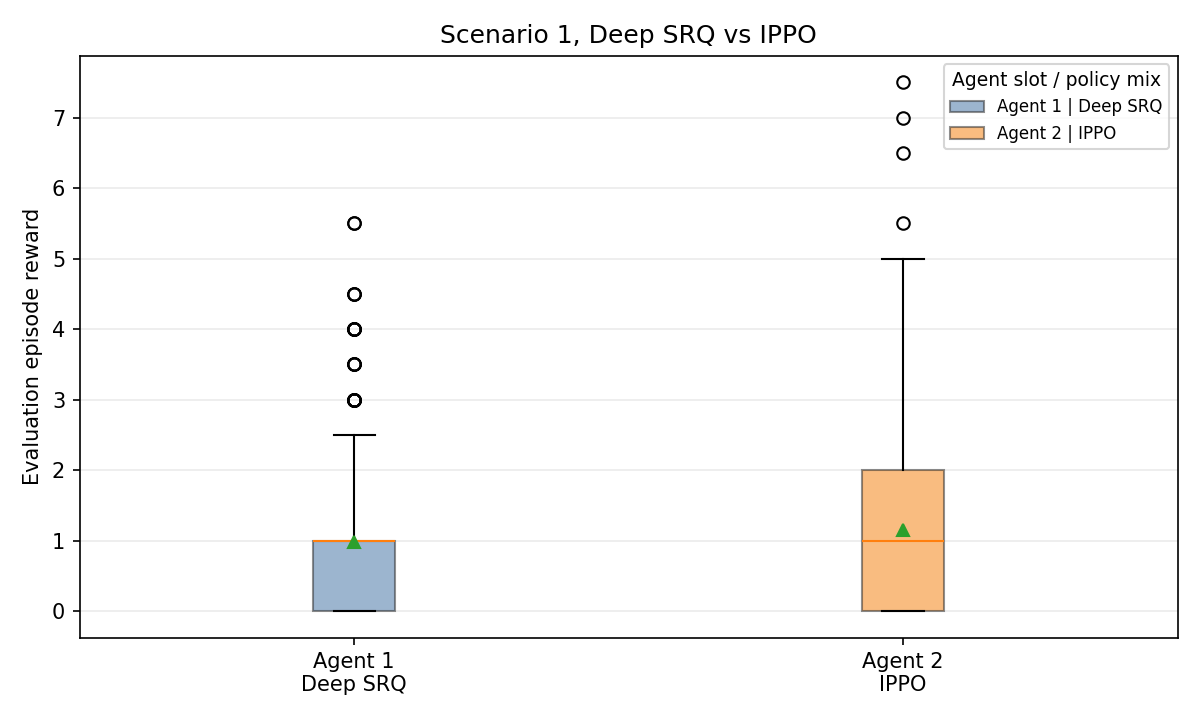

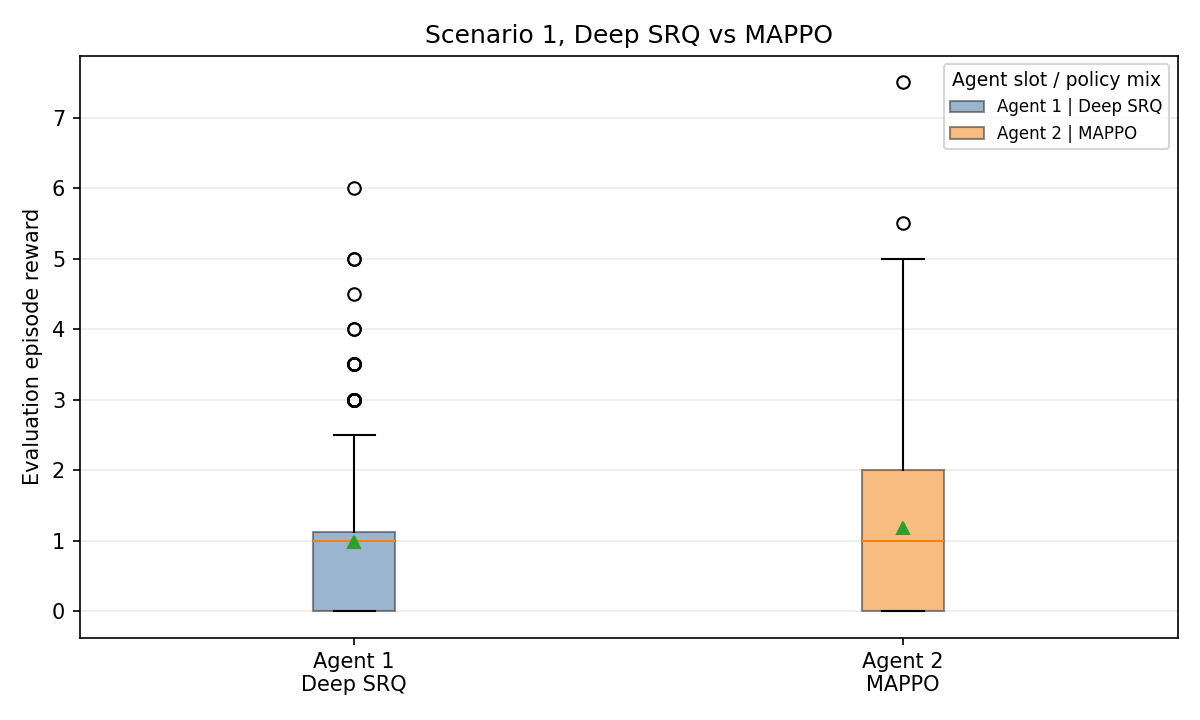

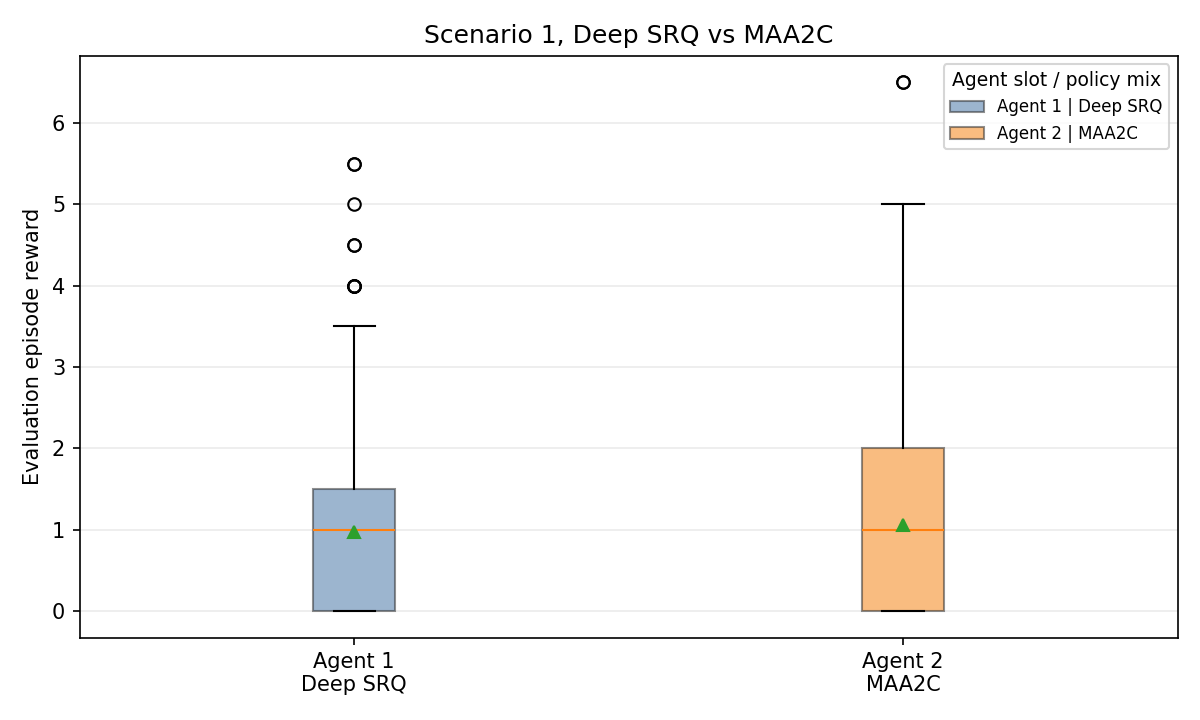

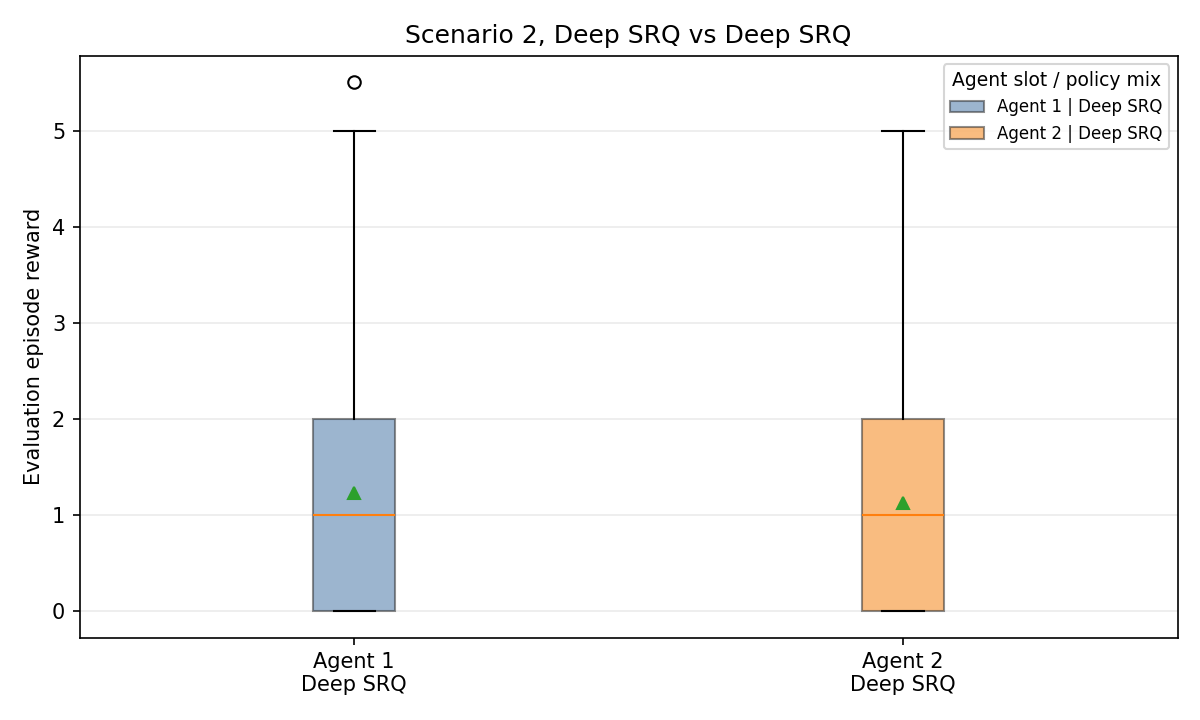

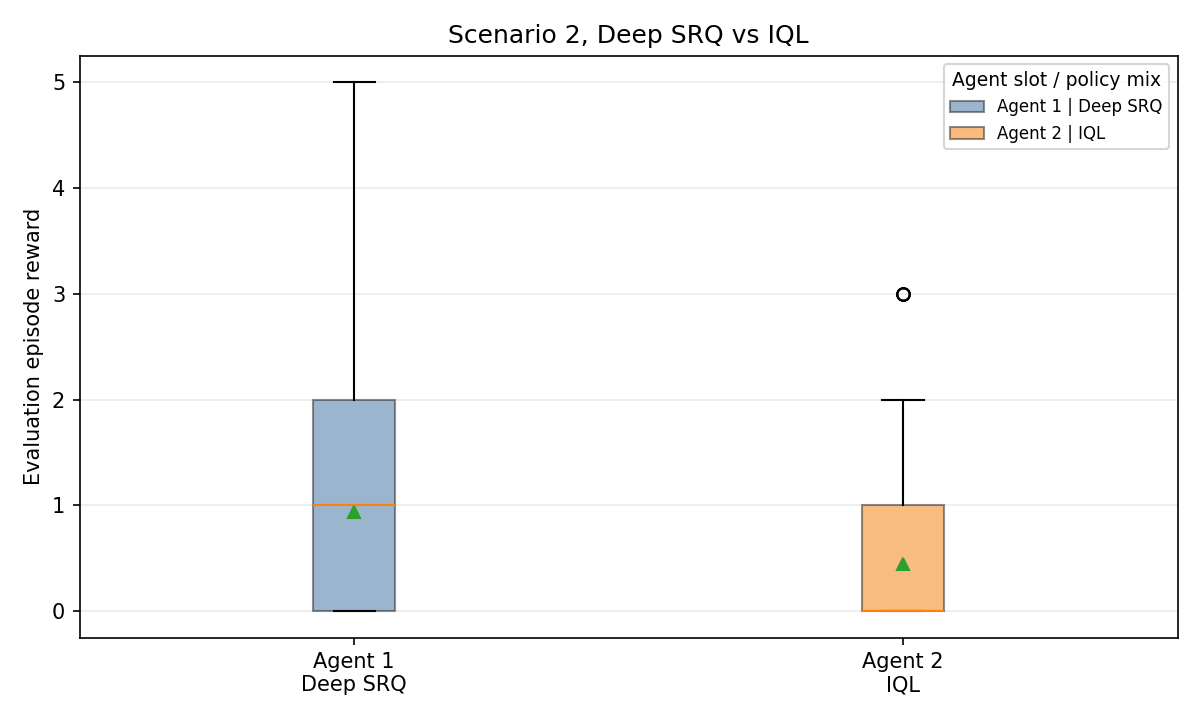

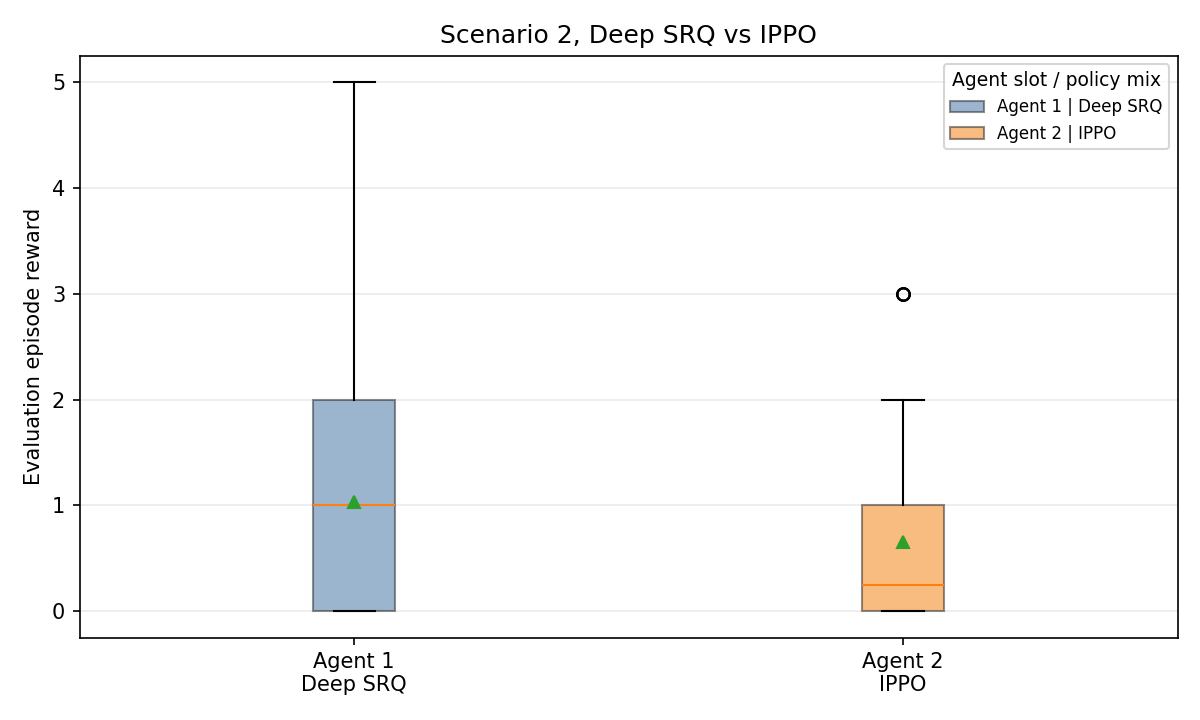

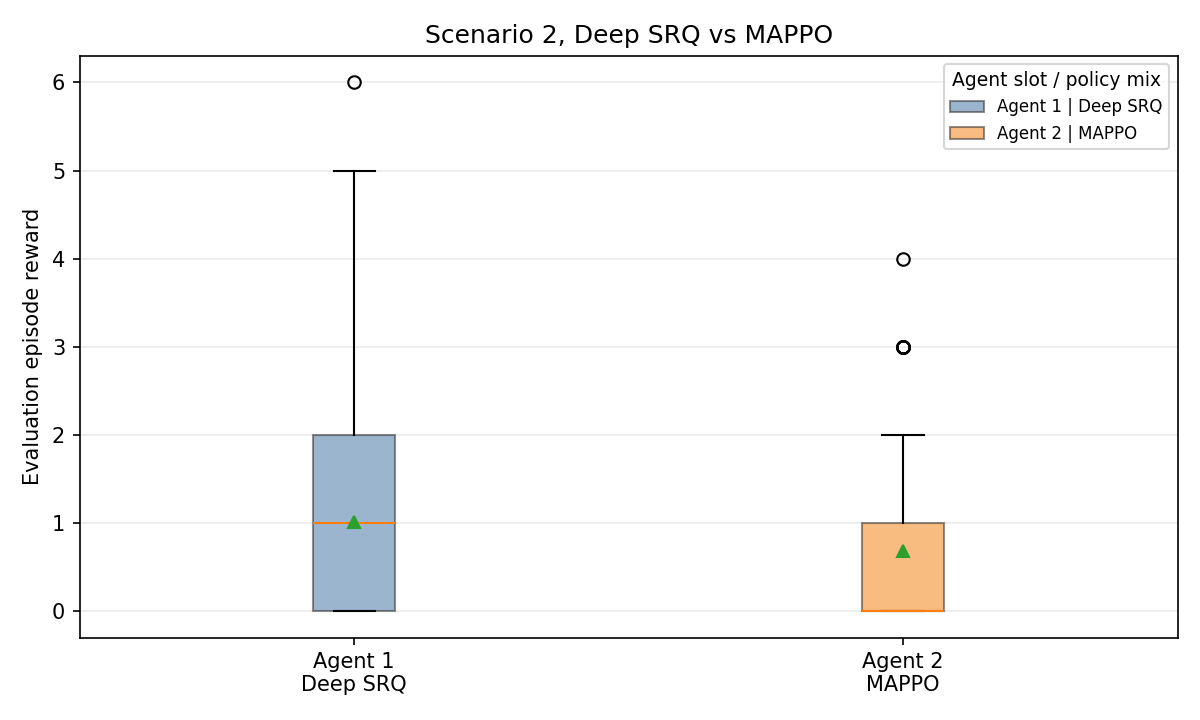

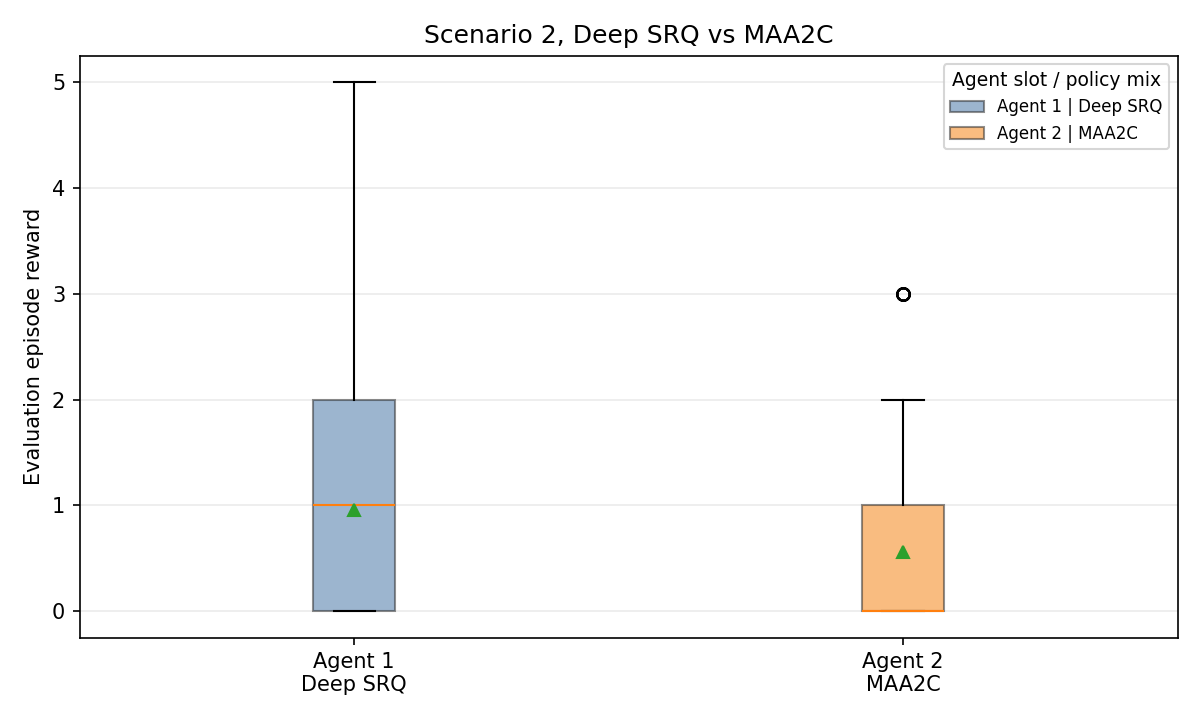

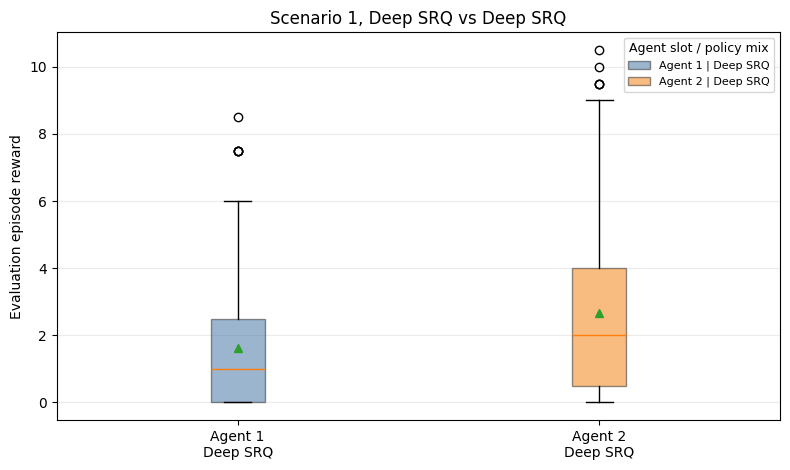

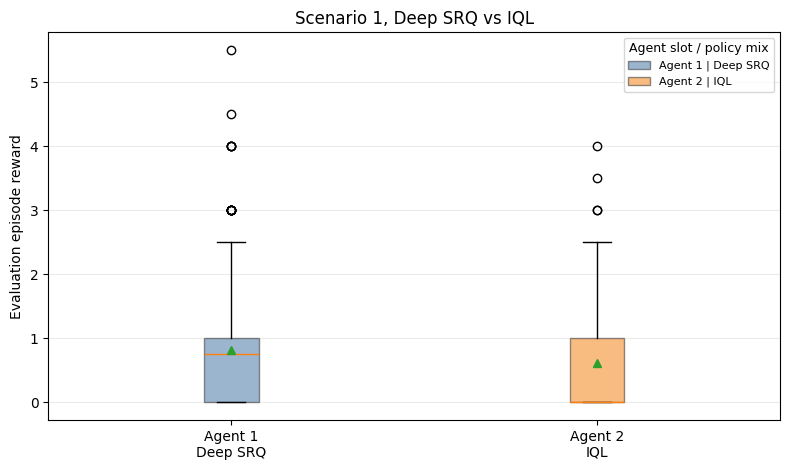

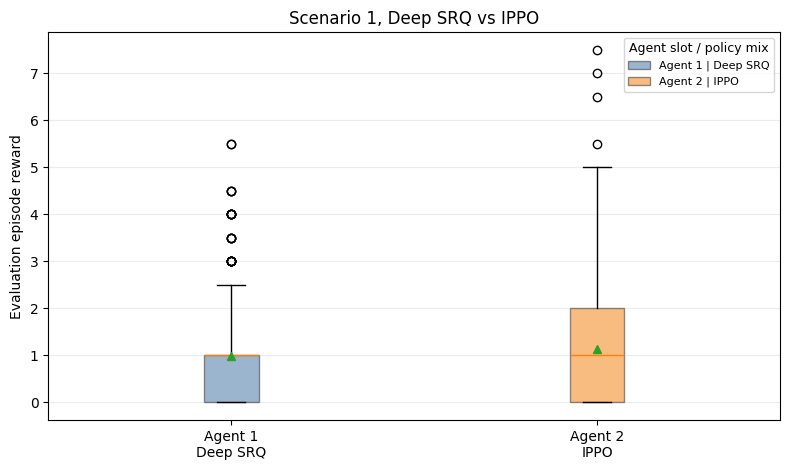

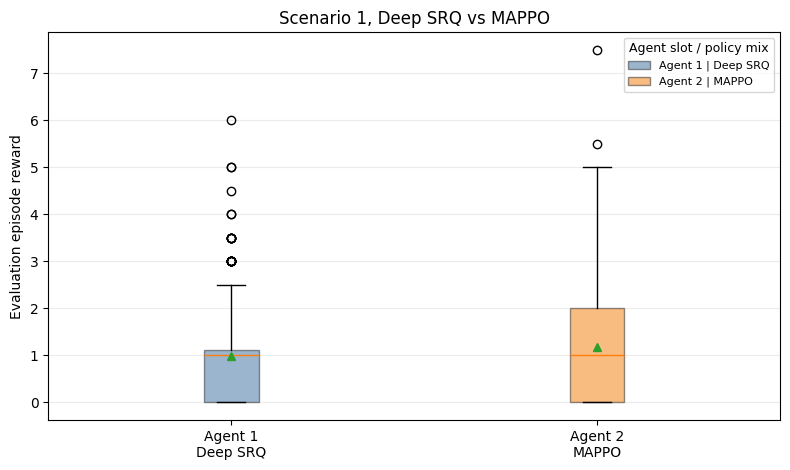

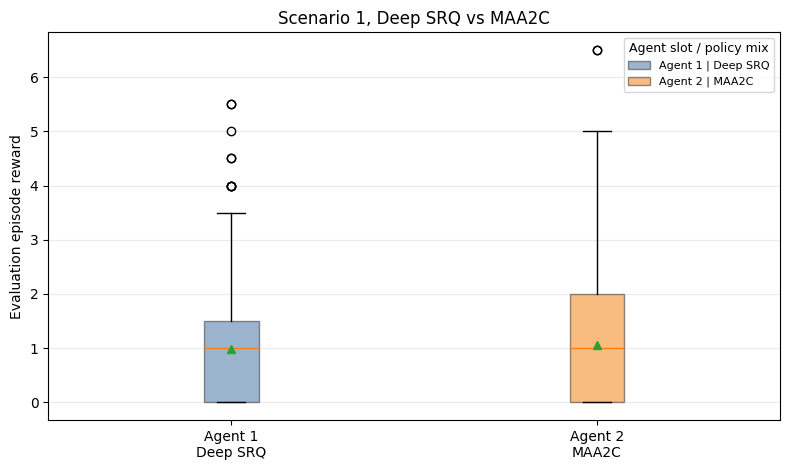

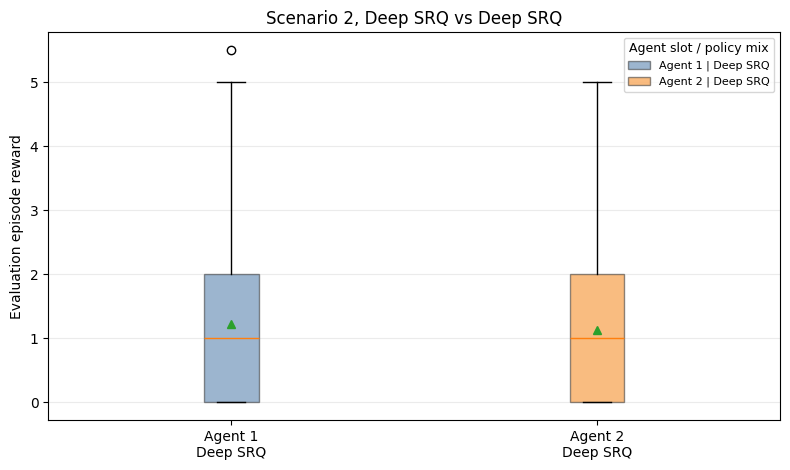

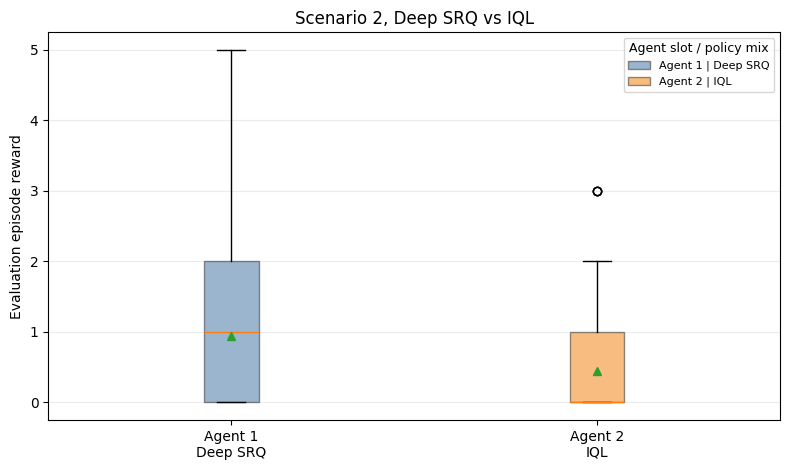

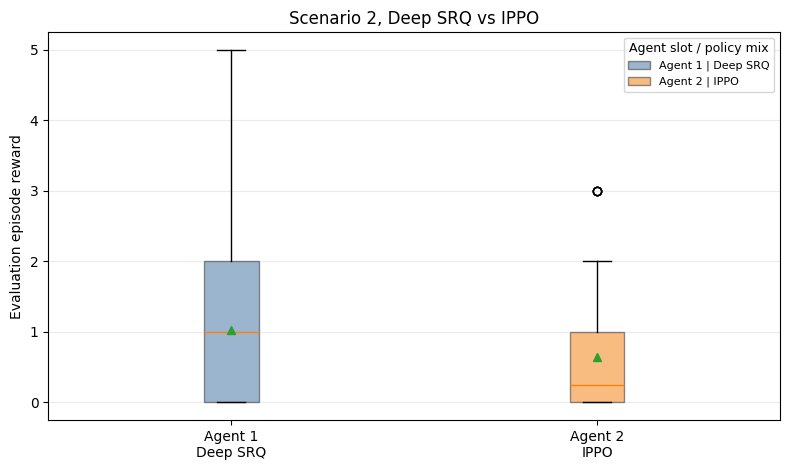

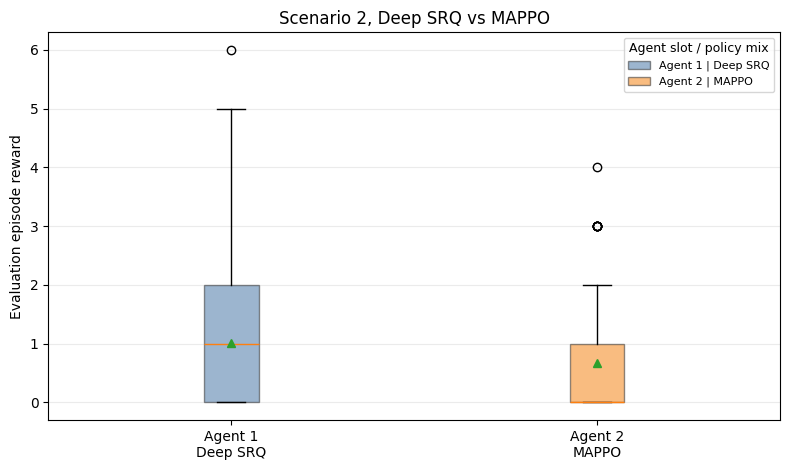

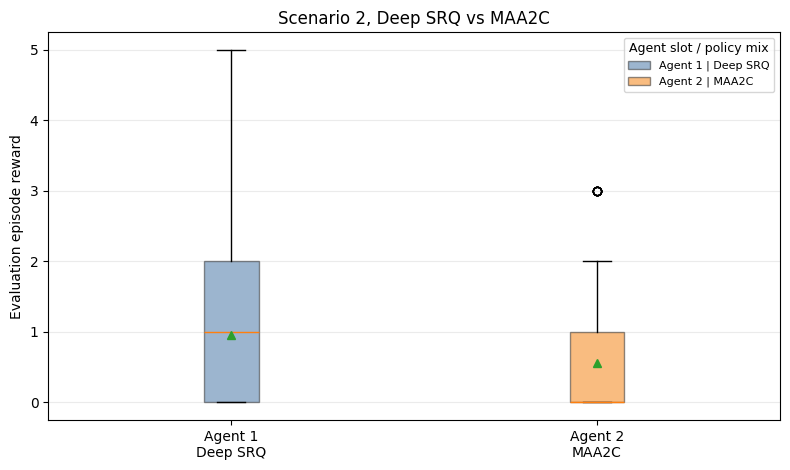

In [8]:
deep_srq_path_pool_eval_eps_0_5 = evaluate_deepsrq_path_mcp_pool_suite_for_epsilon(
    0.5,
    scenarios=SCENARIOS,
    n_episodes=EVAL_EPISODES,
    repo_root=REPO_ROOT,
    use_gpu=USE_GPU,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=EVAL_NUM_ENVS,
    hyperparameter_overrides=PATH_MCP_HYPERPARAMETER_OVERRIDES,
    nplayer_solver_name=PATH_POOL_NPLAYER_SOLVER,
)
display_evaluation_boxplots(deep_srq_path_pool_eval_eps_0_5)


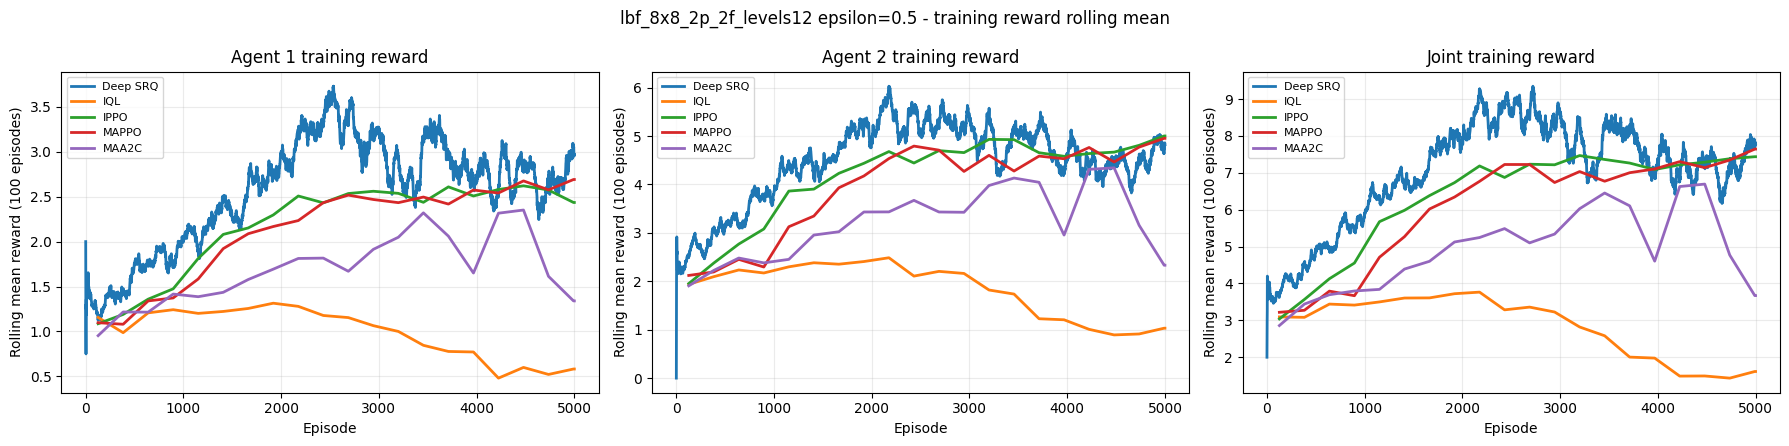

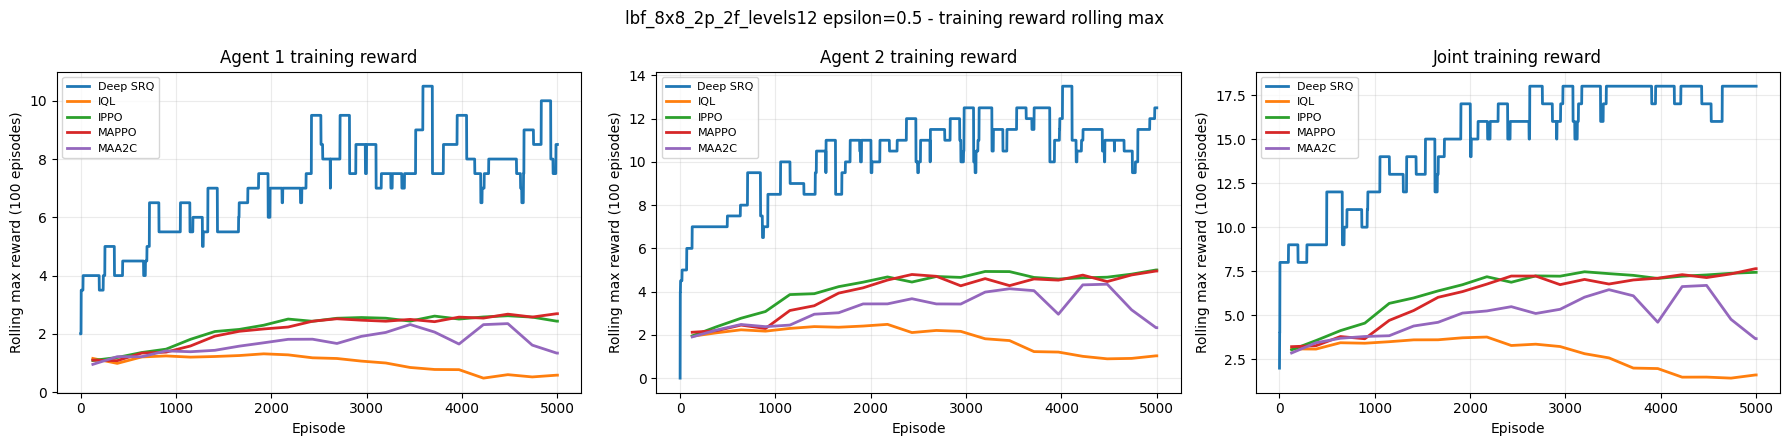

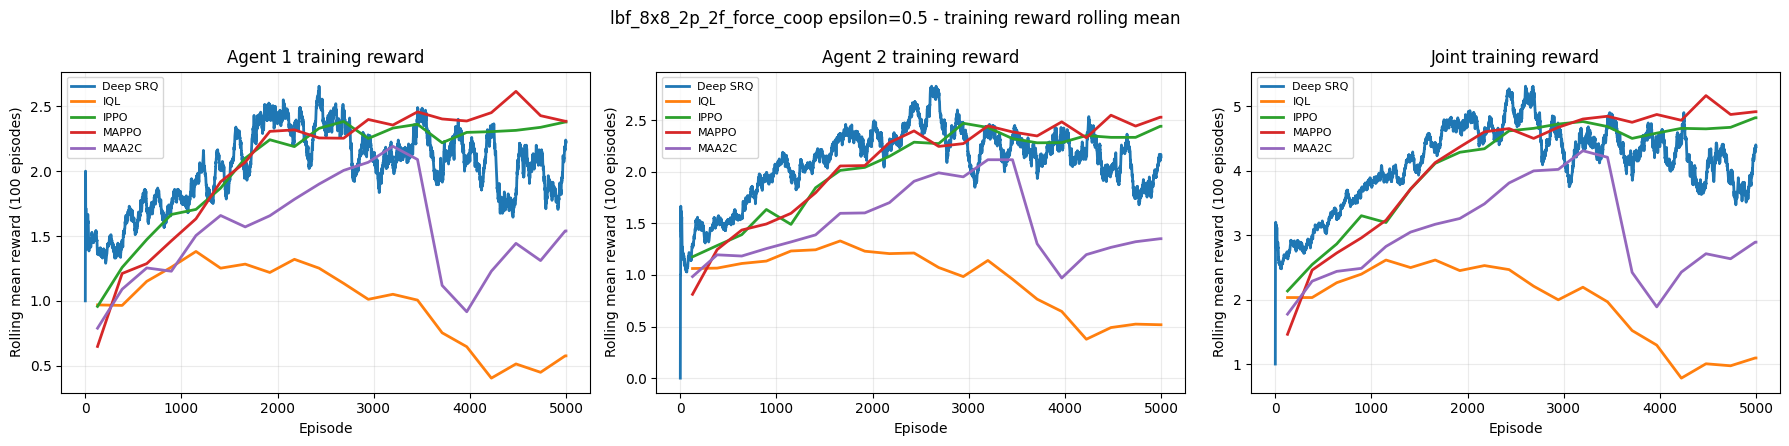

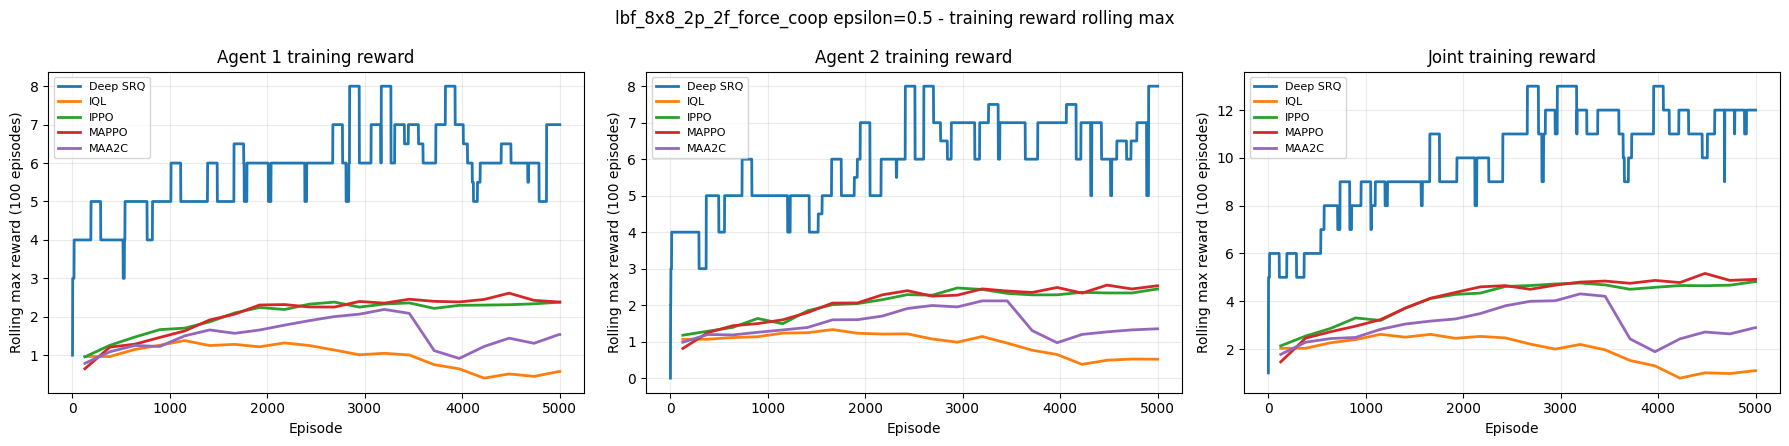

In [9]:
# PATH_POOL_TRAINING_REWARD_COMPARISON_CALL
plot_path_pool_training_reward_comparisons(0.5, scenarios=SCENARIOS)


## Robust epsilon 1

lbf_8x8_2p_2f_levels12 | Deep SRQ:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs IQL:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs IPPO:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs MAPPO:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_levels12 | Deep SRQ vs MAA2C:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ vs IQL:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ vs IPPO:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ vs MAPPO:   0%|          | 0/200 [00:00<?, ?episode/s]

lbf_8x8_2p_2f_force_coop | Deep SRQ vs MAA2C:   0%|          | 0/200 [00:00<?, ?episode/s]

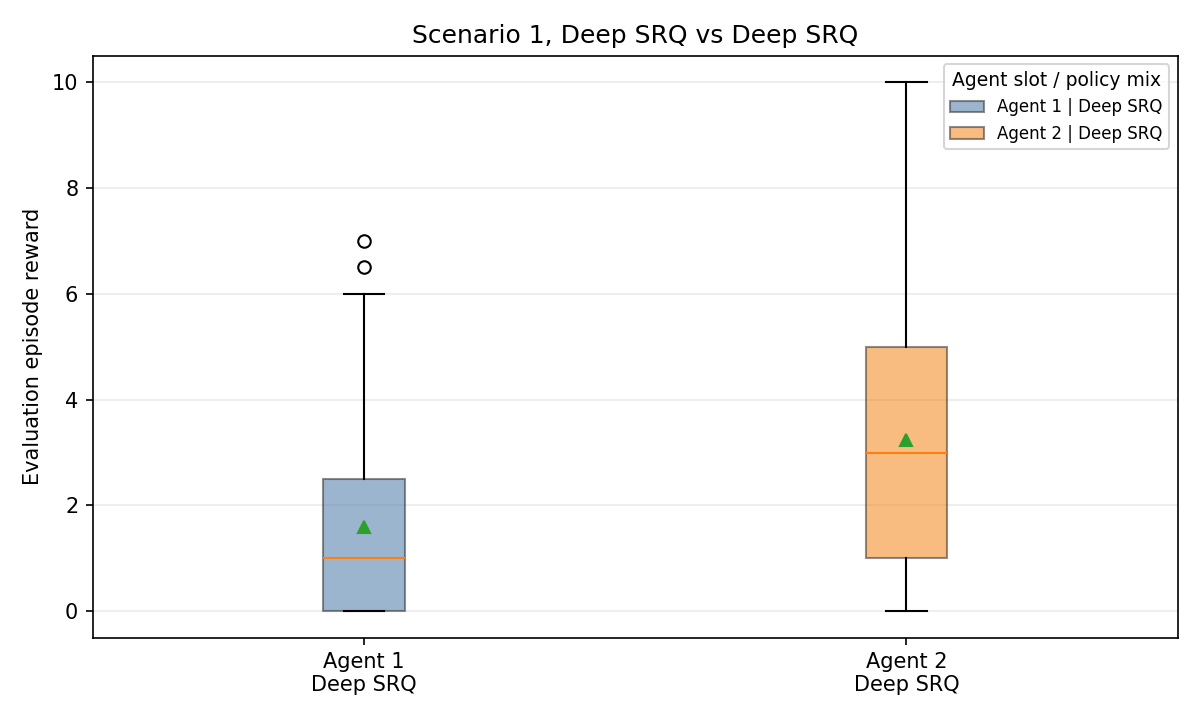

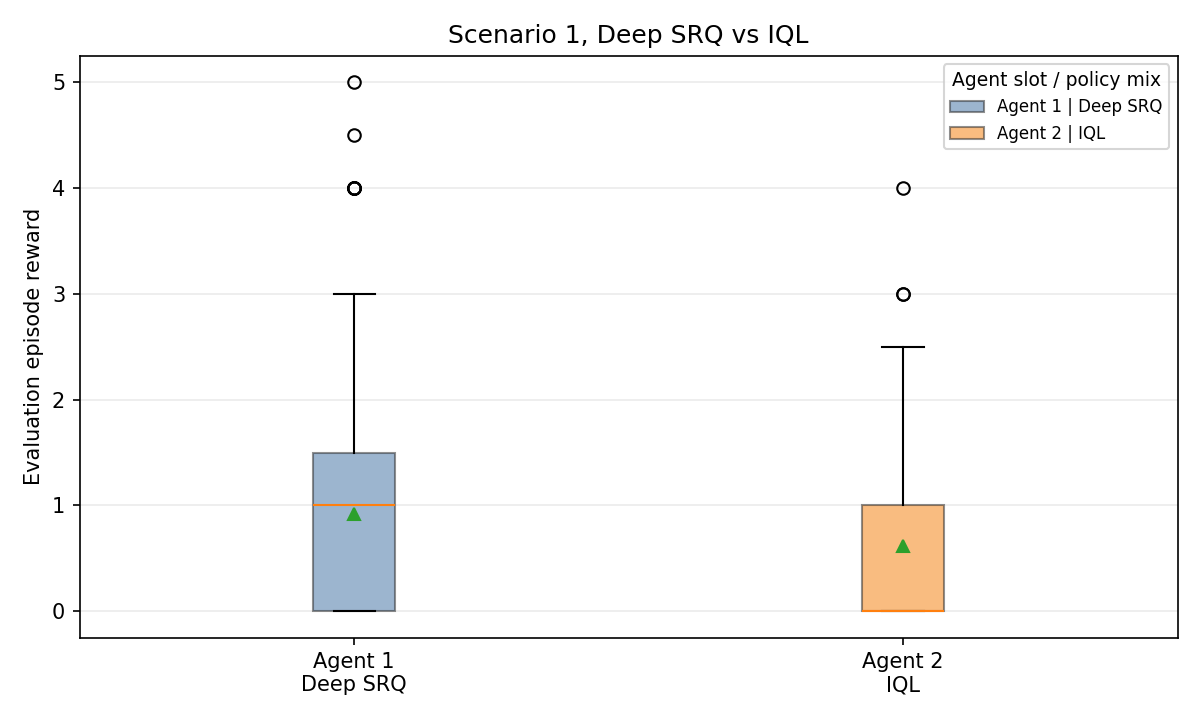

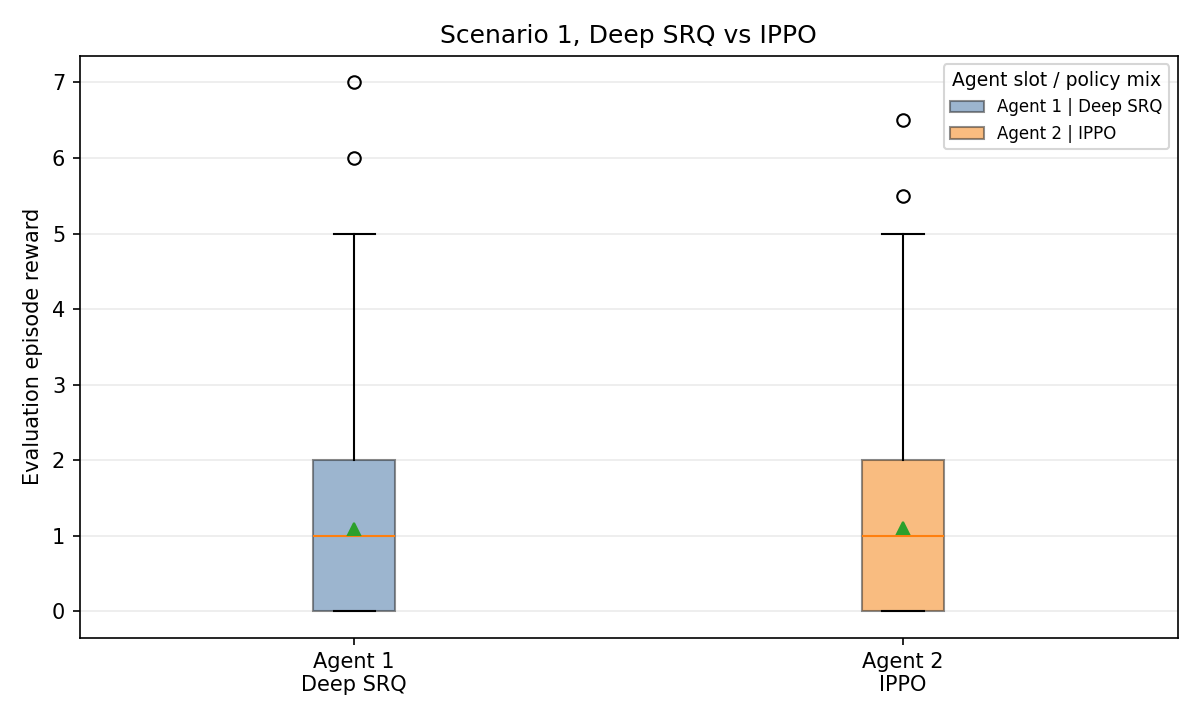

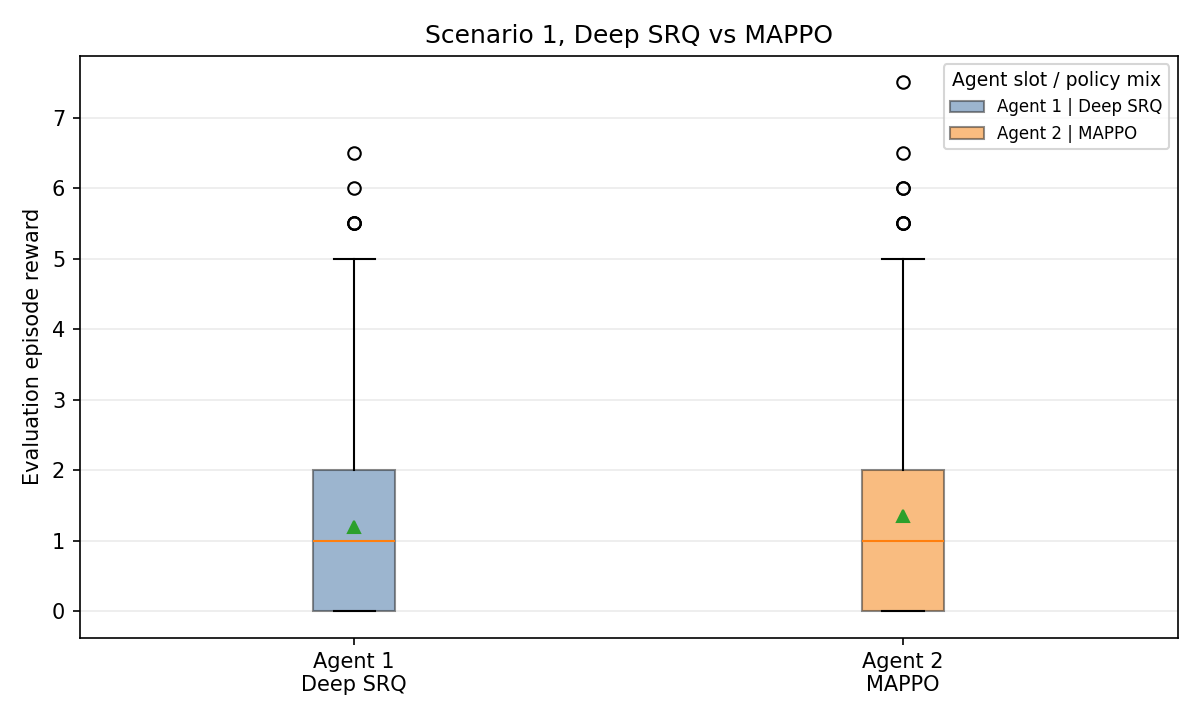

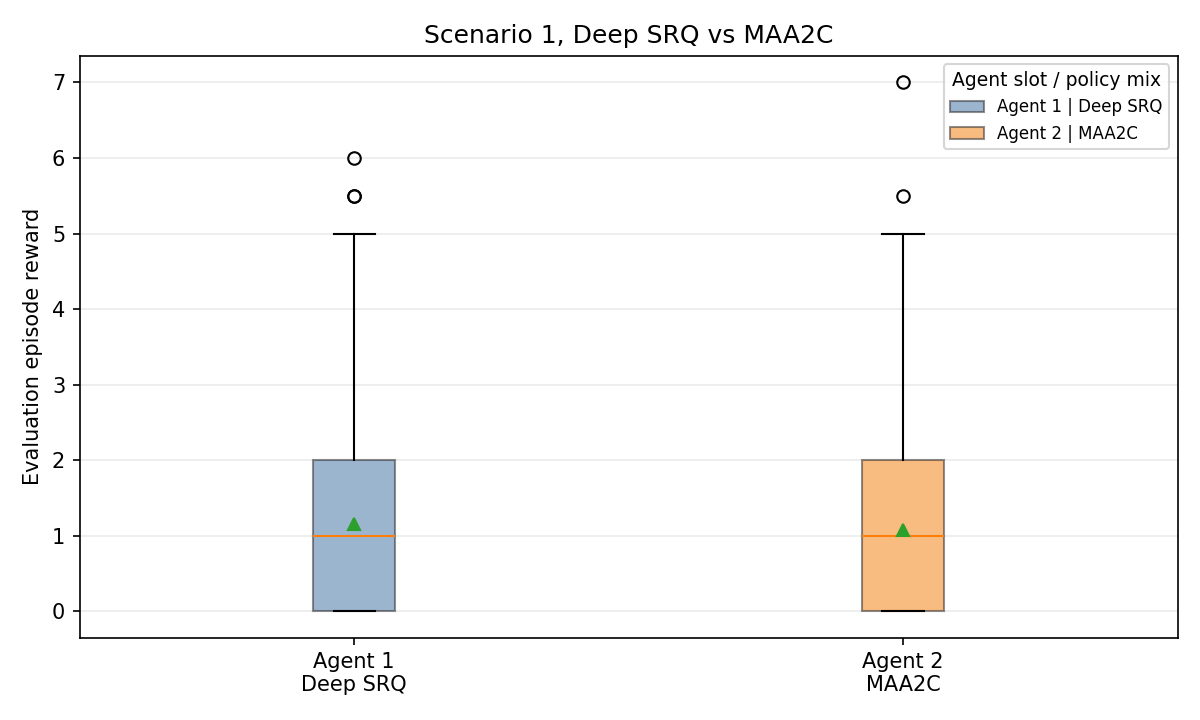

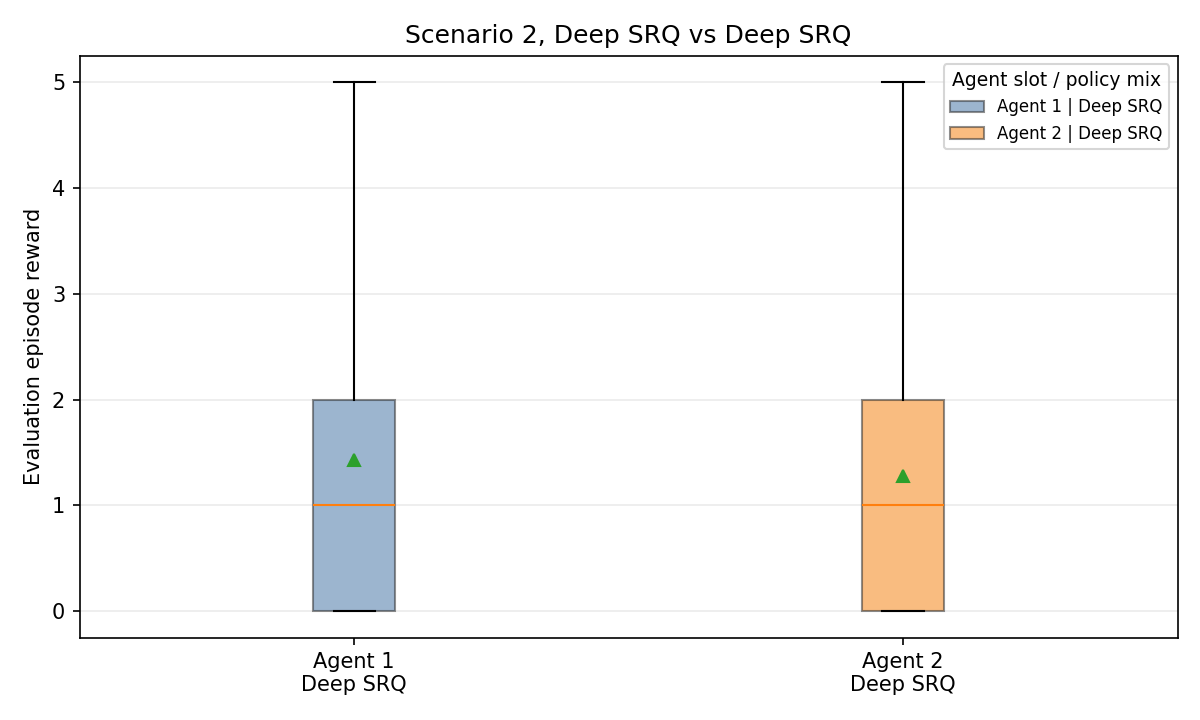

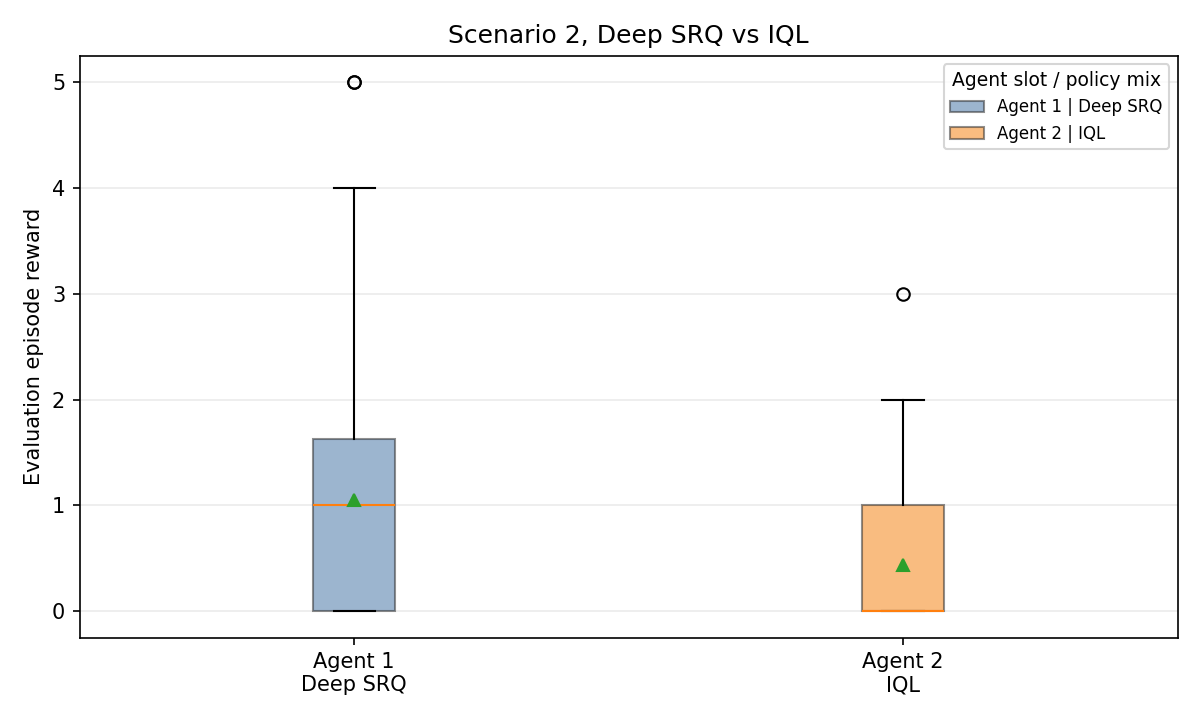

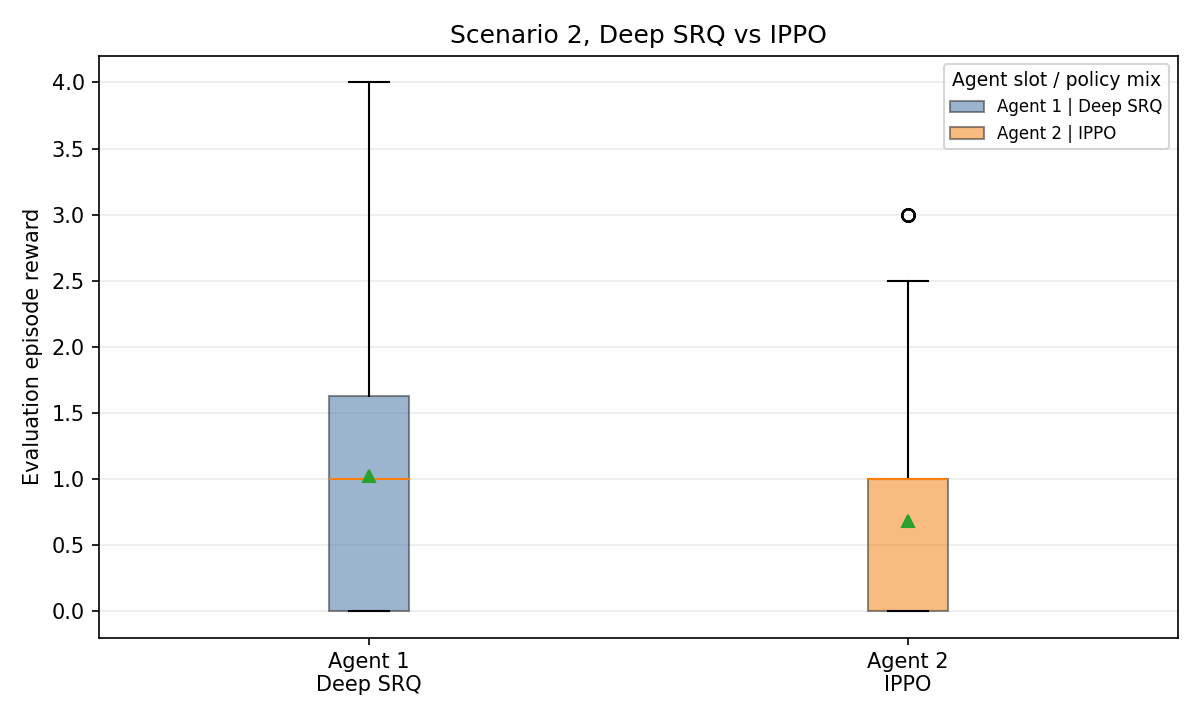

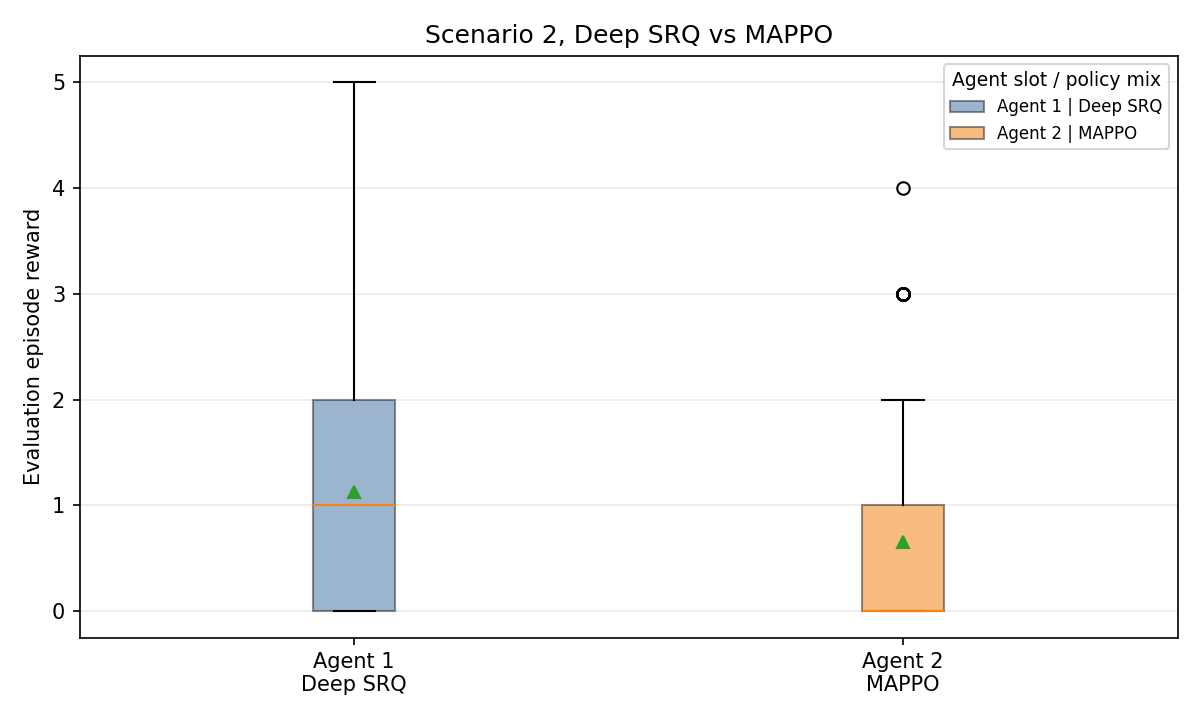

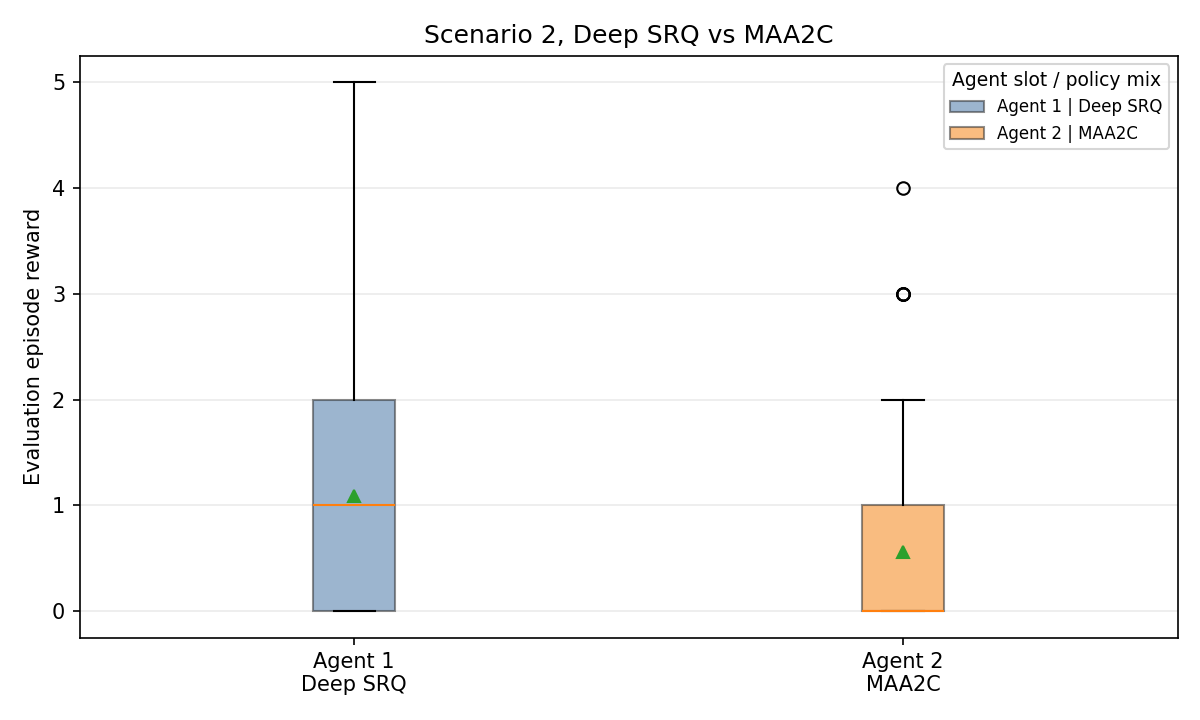

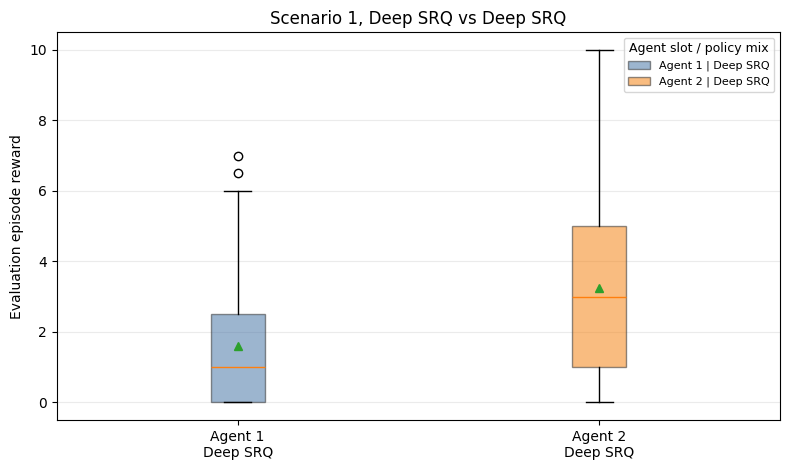

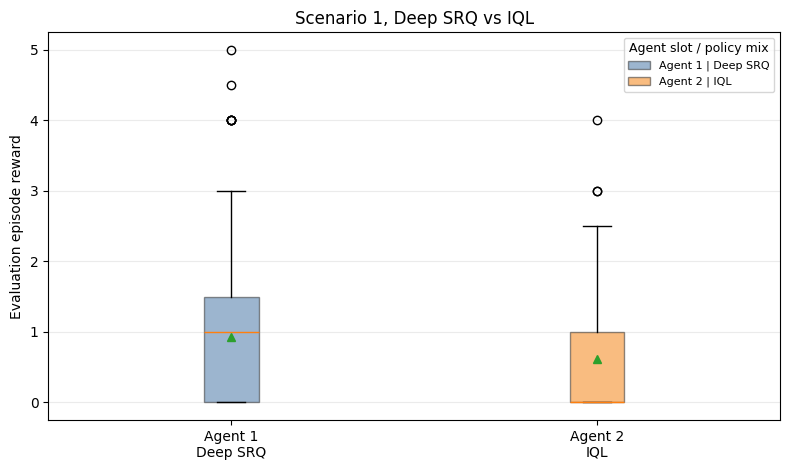

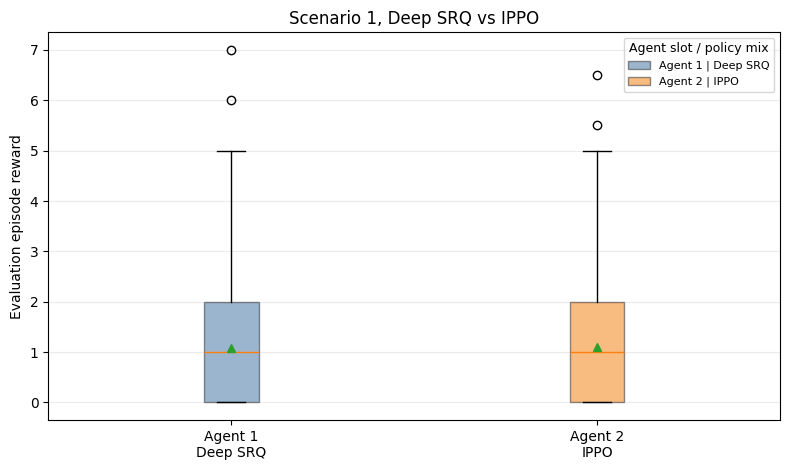

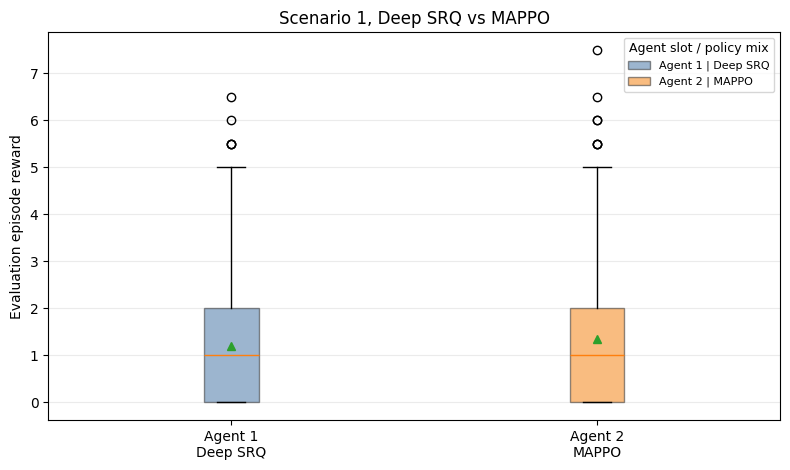

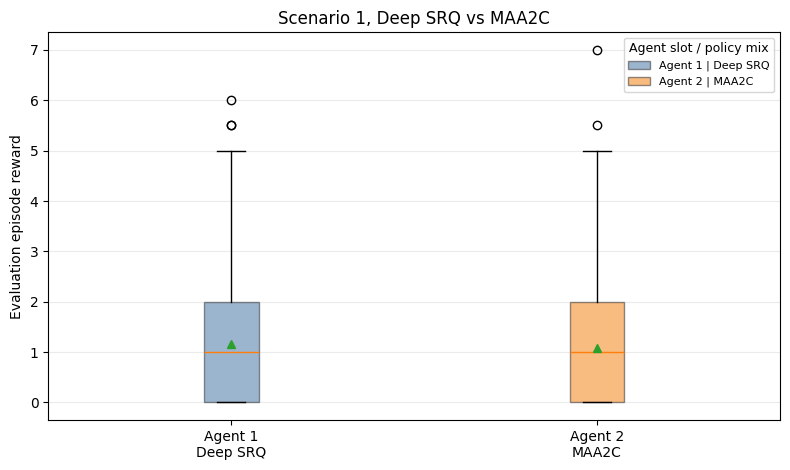

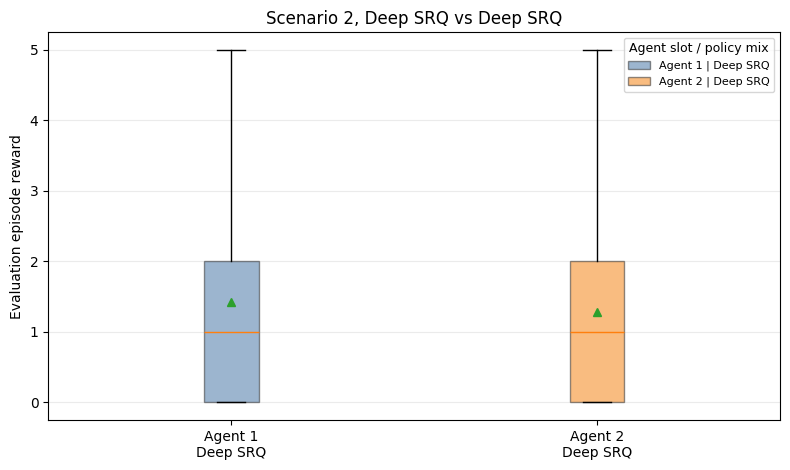

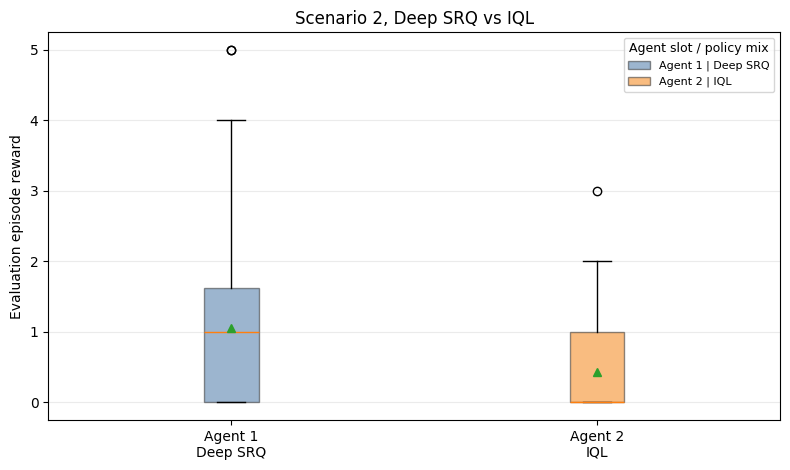

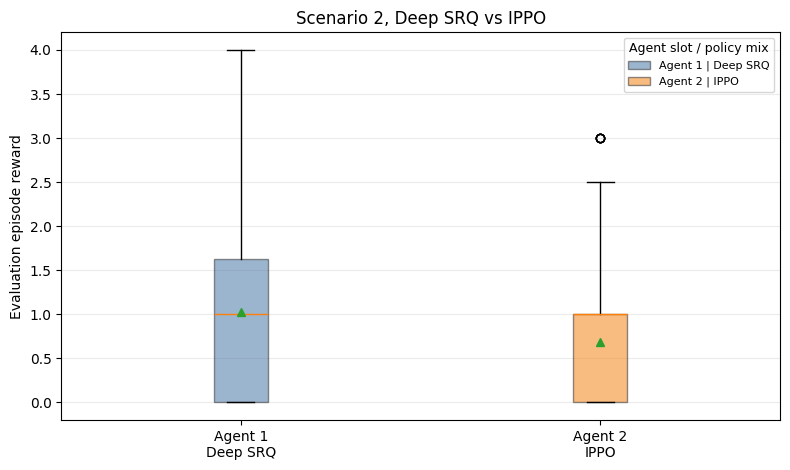

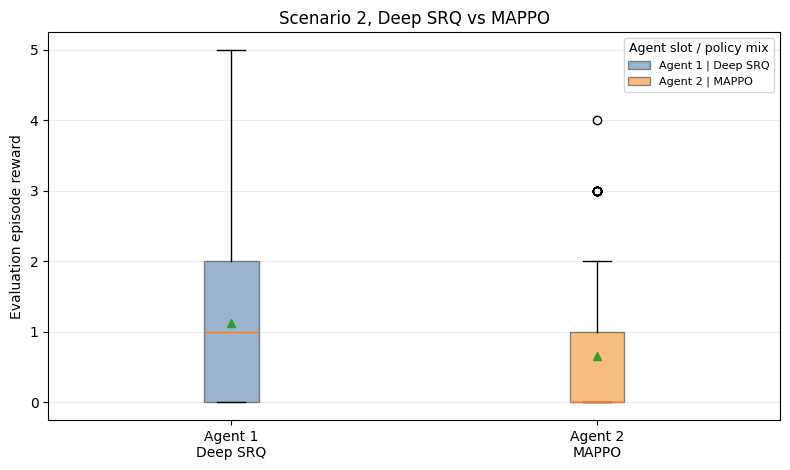

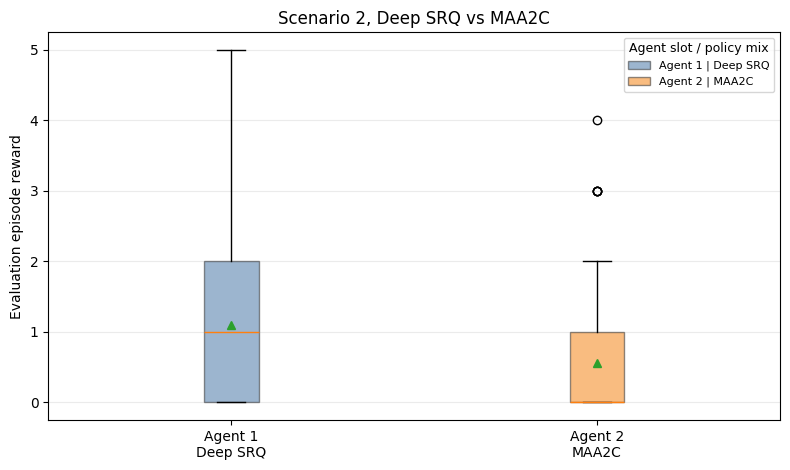

In [10]:
deep_srq_path_pool_eval_eps_1_0 = evaluate_deepsrq_path_mcp_pool_suite_for_epsilon(
    1.0,
    scenarios=SCENARIOS,
    n_episodes=EVAL_EPISODES,
    repo_root=REPO_ROOT,
    use_gpu=USE_GPU,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=EVAL_NUM_ENVS,
    hyperparameter_overrides=PATH_MCP_HYPERPARAMETER_OVERRIDES,
    nplayer_solver_name=PATH_POOL_NPLAYER_SOLVER,
)
display_evaluation_boxplots(deep_srq_path_pool_eval_eps_1_0)


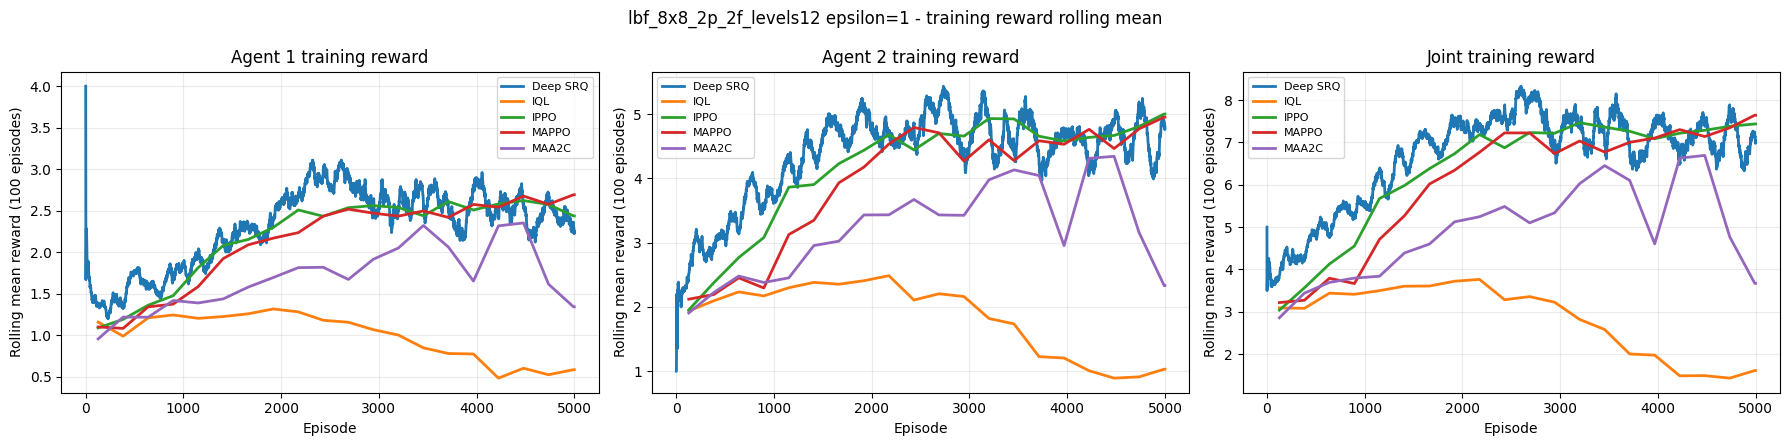

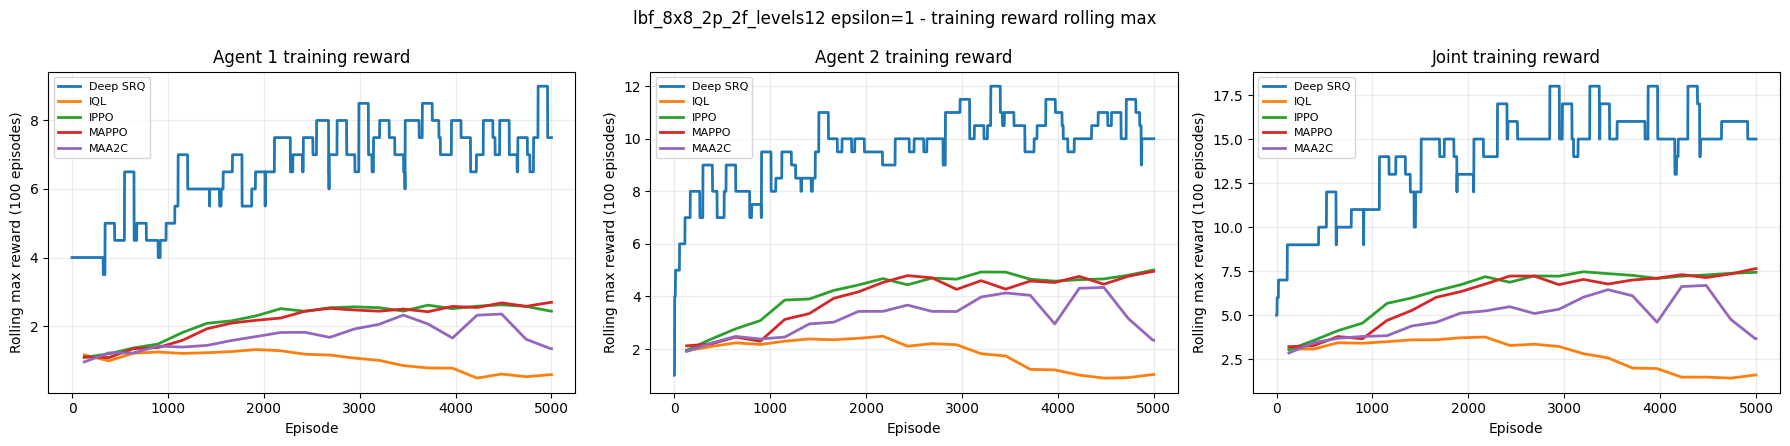

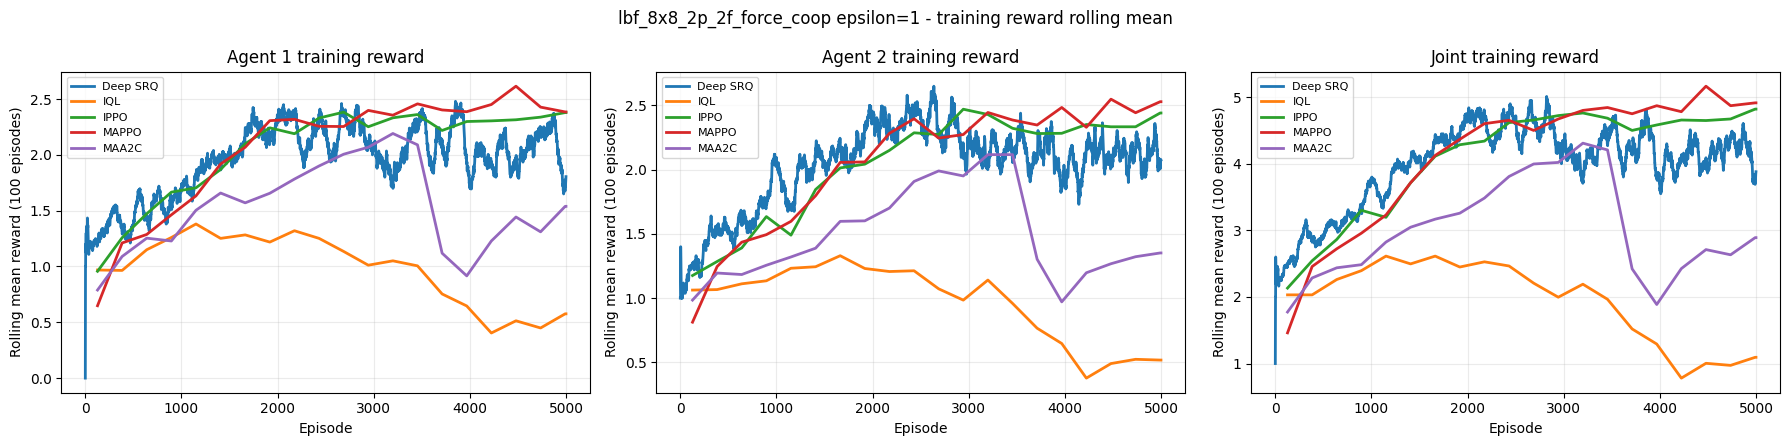

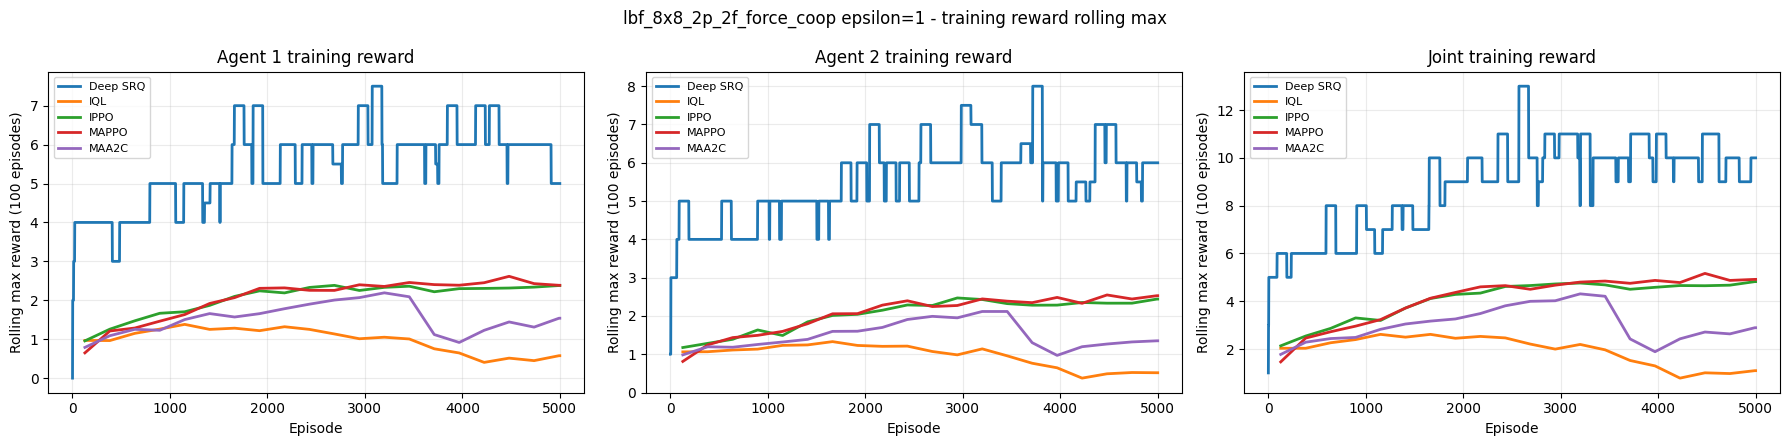

In [11]:
# PATH_POOL_TRAINING_REWARD_COMPARISON_CALL
plot_path_pool_training_reward_comparisons(1.0, scenarios=SCENARIOS)
